# Matplotlib: From Basics to Advanced

**Purpose:** Learn matplotlib so you can read and understand the plotting code in ML/AI projects.

Every ML project visualizes data — EDA plots, training curves, confusion matrices, feature importance charts. Matplotlib is the foundation that seaborn, pandas `.plot()`, and most ML visualization tools are built on.

**How this notebook is organized:**
1. The Two Interfaces (pyplot vs OOP)
2. Line Plots (training curves, time series)
3. Scatter Plots (feature relationships, clusters)
4. Bar Charts (feature importance, class distribution)
5. Histograms (data distributions)
6. Subplots (multiple plots in one figure)
7. Customization (labels, legends, colors, styles)
8. Heatmaps (confusion matrices, correlation)
9. Box & Violin Plots (distribution comparison)
10. Saving Figures
11. Real ML/AI Plotting Patterns

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# This magic command makes plots appear inline in Jupyter
%matplotlib inline

# Optional: make plots look sharper on retina/HiDPI screens
%config InlineBackend.figure_format = 'retina'

print(f"Matplotlib version: {matplotlib.__version__}")

Matplotlib version: 3.10.6


## 1. The Two Interfaces — pyplot vs Object-Oriented

Matplotlib has two ways to create plots. You'll see BOTH in ML code, so you need to recognize each.

- **pyplot (plt.plot)** — quick and simple, MATLAB-style. Good for one-off plots.
- **OOP (fig, ax)** — more control, used in production code and when you need subplots.

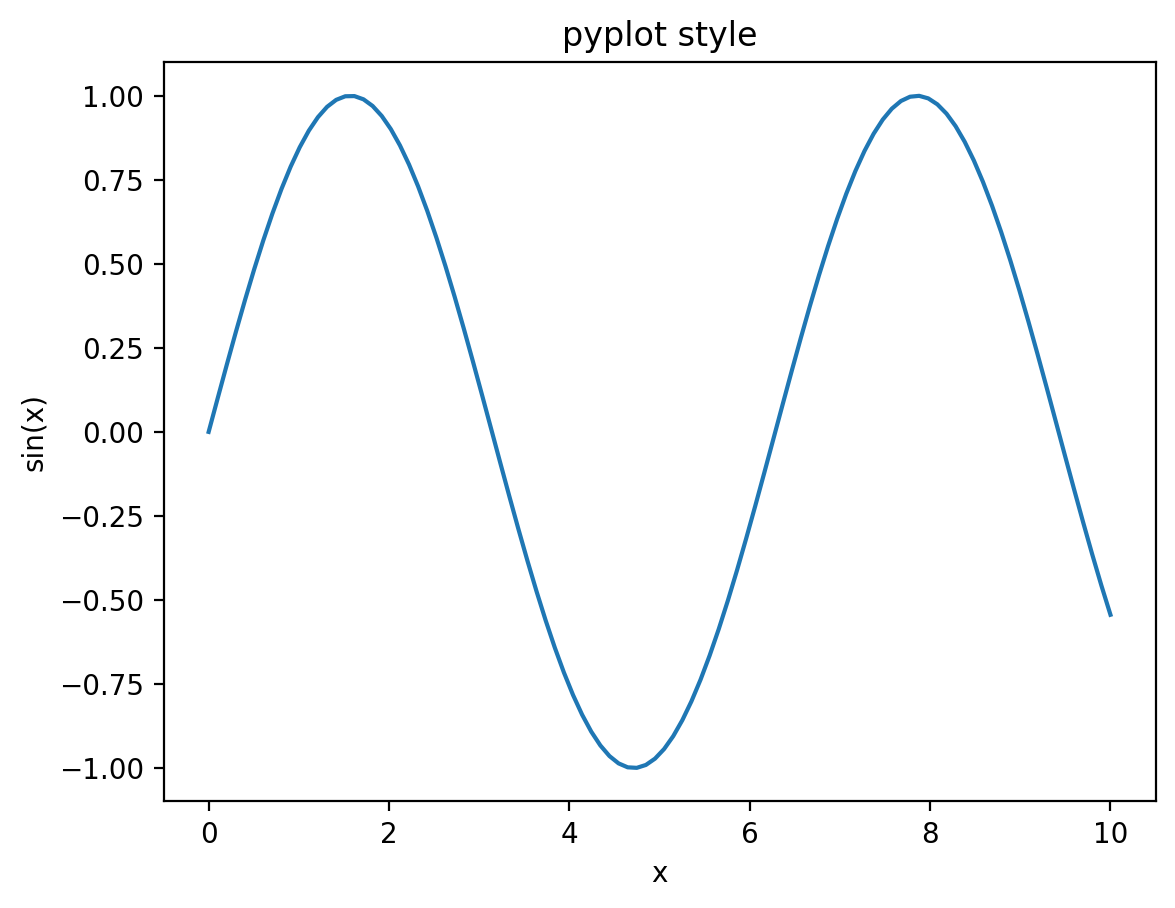

In [2]:
# STYLE 1: pyplot interface — plt.something()
# Quick, implicit "current figure" and "current axes"

x = np.linspace(0, 10, 100)

plt.plot(x, np.sin(x))
plt.title("pyplot style")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.show()

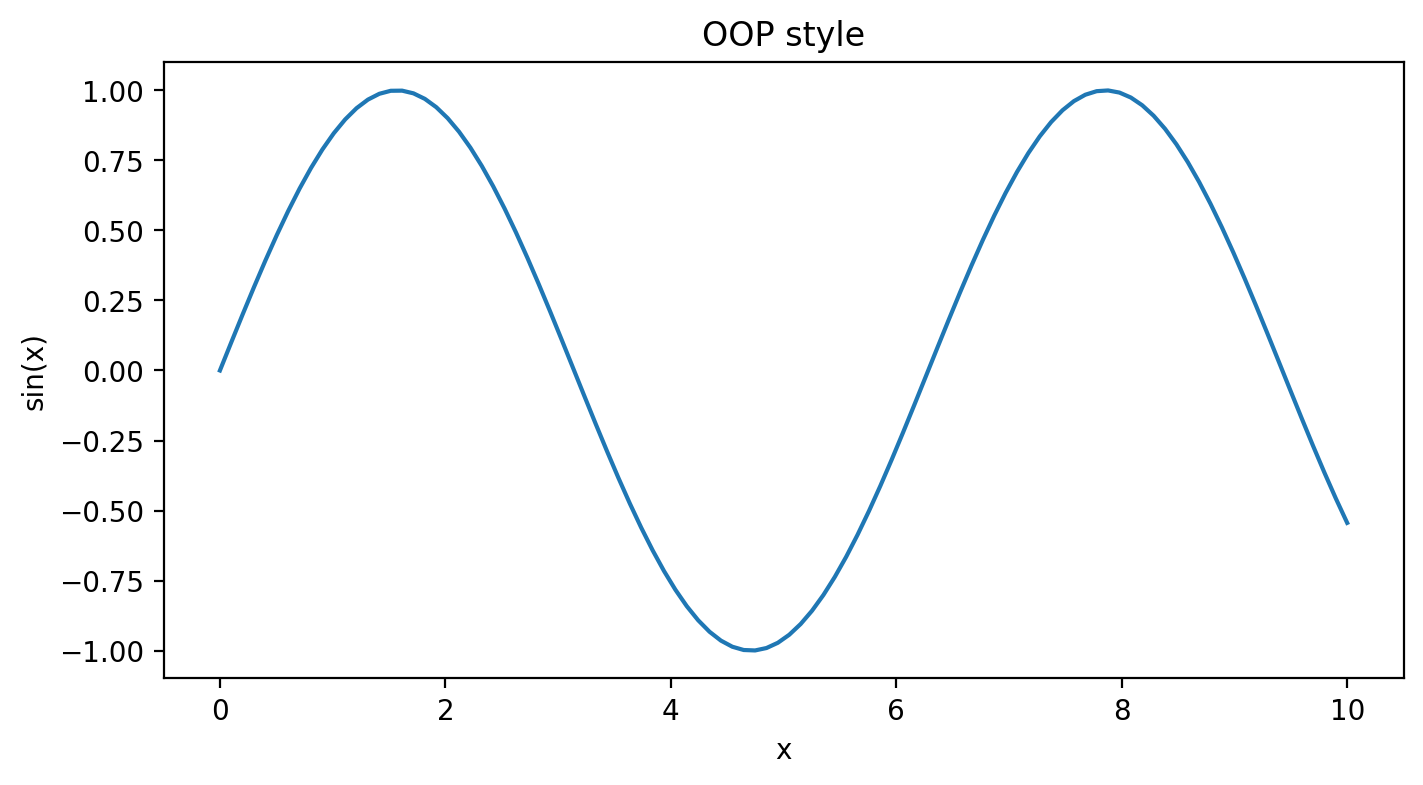

In [3]:
# STYLE 2: Object-oriented interface — fig, ax = plt.subplots()
# More explicit, preferred in ML code with multiple plots

fig, ax = plt.subplots(figsize=(8, 4))  # figsize = (width, height) in inches

ax.plot(x, np.sin(x))
ax.set_title("OOP style")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
plt.show()

# Key difference: plt.title() vs ax.set_title()
#                 plt.xlabel() vs ax.set_xlabel()
# When you see "ax." — it's OOP style. When you see "plt." — it's pyplot style.

## 2. Line Plots

The most common plot in ML — used for training/loss curves, time series, and metric tracking.

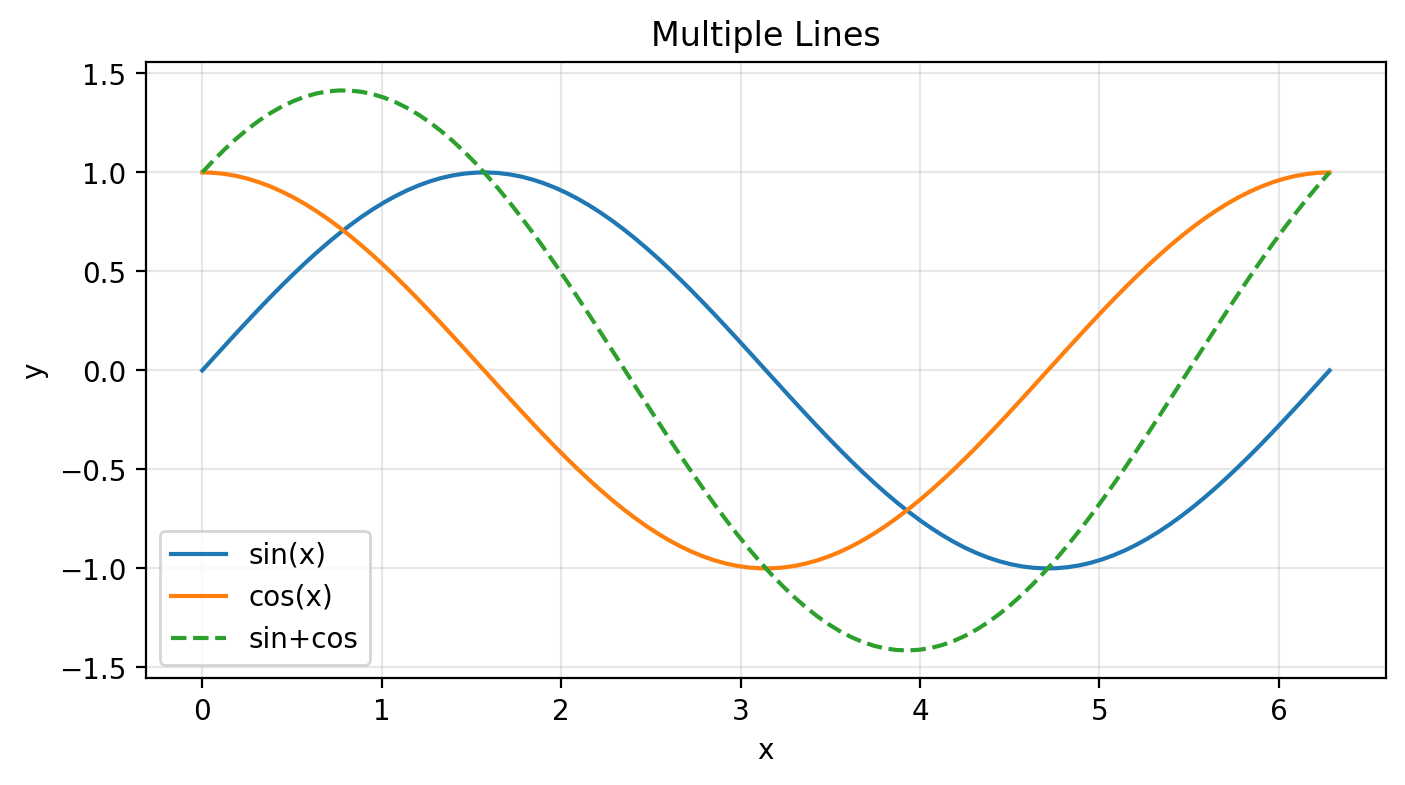

In [4]:
# Basic line plot with multiple lines
x = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sin(x), label='sin(x)')
ax.plot(x, np.cos(x), label='cos(x)')
ax.plot(x, np.sin(x) + np.cos(x), label='sin+cos', linestyle='--')

ax.set_title("Multiple Lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()  # Shows the labels
ax.grid(True, alpha=0.3)  # Light grid
plt.show()

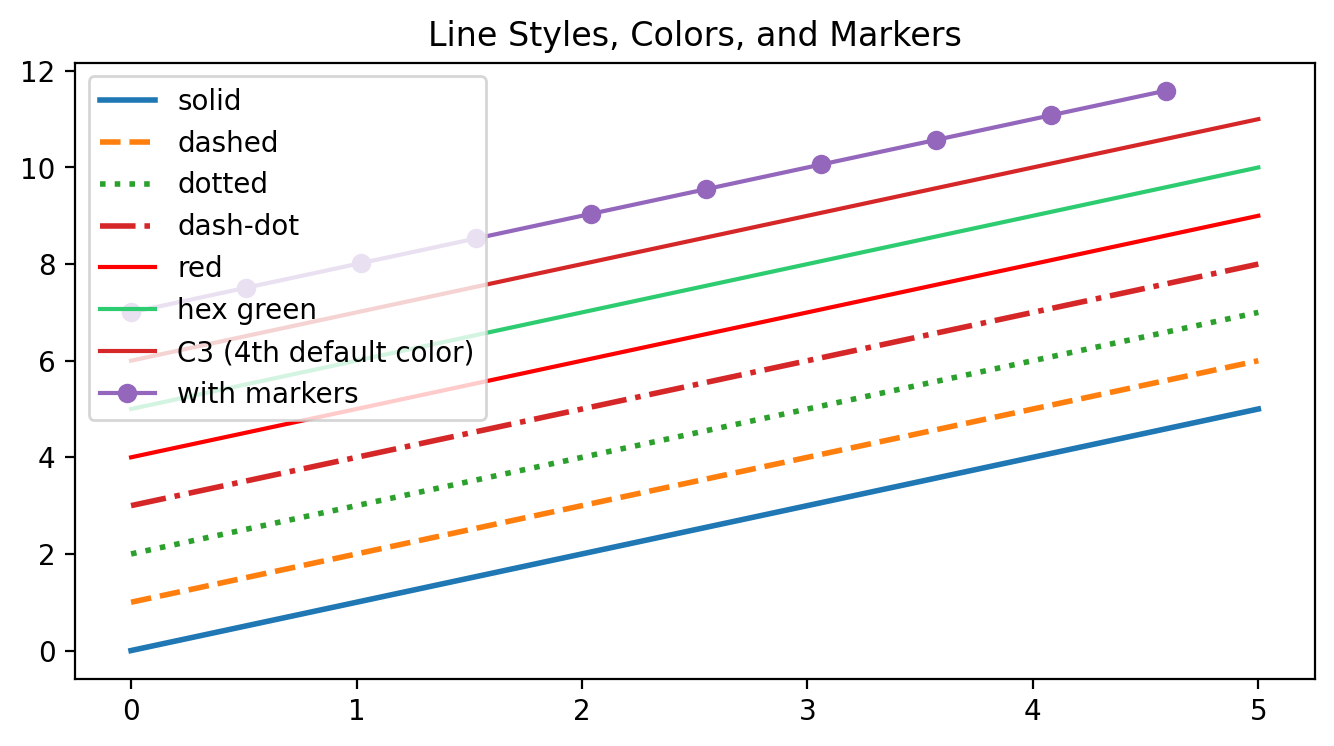

In [5]:
# Line style options you'll encounter in ML code
fig, ax = plt.subplots(figsize=(8, 4))

x = np.linspace(0, 5, 50)

# linestyle: '-' solid, '--' dashed, ':' dotted, '-.' dash-dot
ax.plot(x, x,      linestyle='-',  linewidth=2, label='solid')
ax.plot(x, x+1,    linestyle='--', linewidth=2, label='dashed')
ax.plot(x, x+2,    linestyle=':',  linewidth=2, label='dotted')
ax.plot(x, x+3,    linestyle='-.', linewidth=2, label='dash-dot')

# Color: can use names, hex codes, or shorthand
ax.plot(x, x+4, color='red',     label='red')
ax.plot(x, x+5, color='#2ecc71', label='hex green')
ax.plot(x, x+6, color='C3',      label='C3 (4th default color)')

# Markers: 'o' circle, 's' square, '^' triangle, 'x' cross, '+' plus
ax.plot(x[::5], (x+7)[::5], 'o-', markersize=6, label='with markers')

ax.legend(loc='upper left')
ax.set_title("Line Styles, Colors, and Markers")
plt.show()

## 3. Scatter Plots

Used for visualizing feature relationships, cluster assignments, PCA projections, and prediction vs actual comparisons.

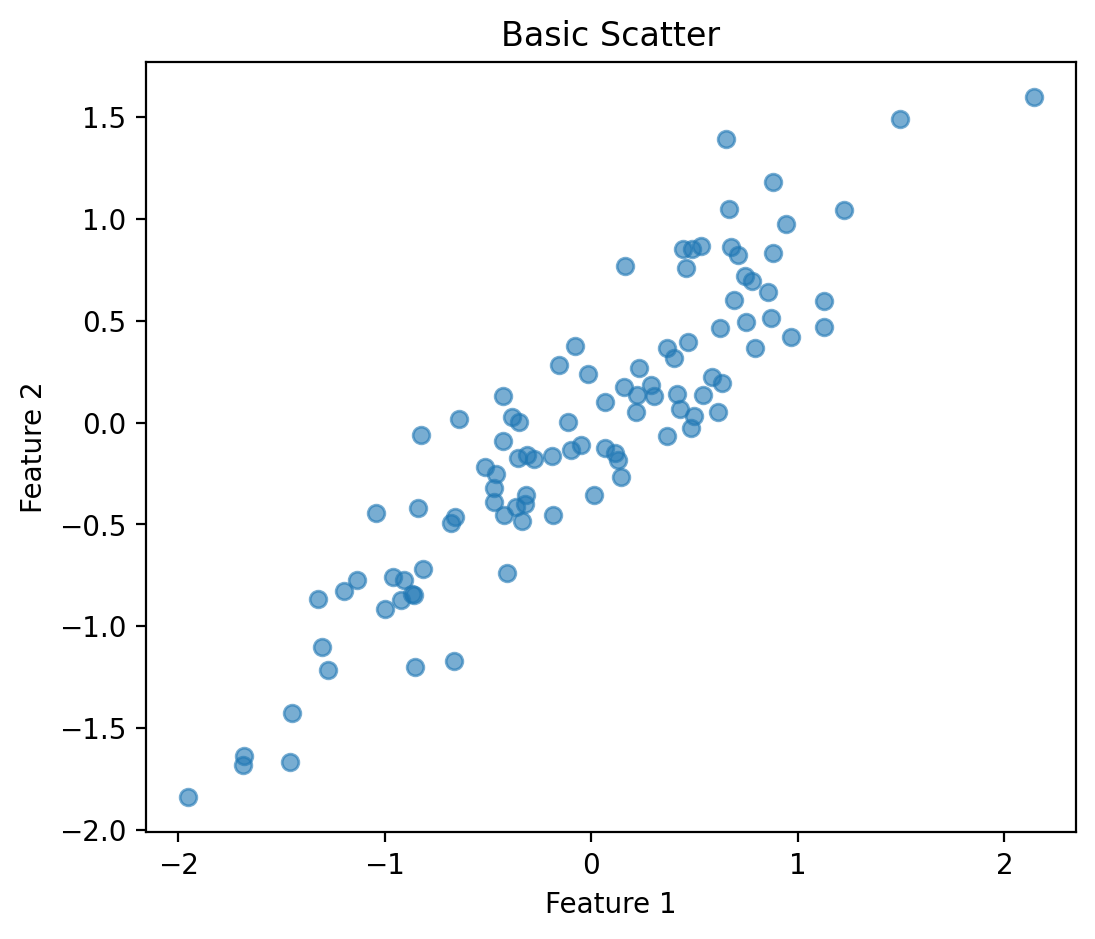

In [6]:
# Basic scatter plot
rng = np.random.default_rng(42)
x = rng.normal(0, 1, 100)
y = x * 0.8 + rng.normal(0, 0.3, 100)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, alpha=0.6)  # alpha = transparency (0-1)
ax.set_title("Basic Scatter")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

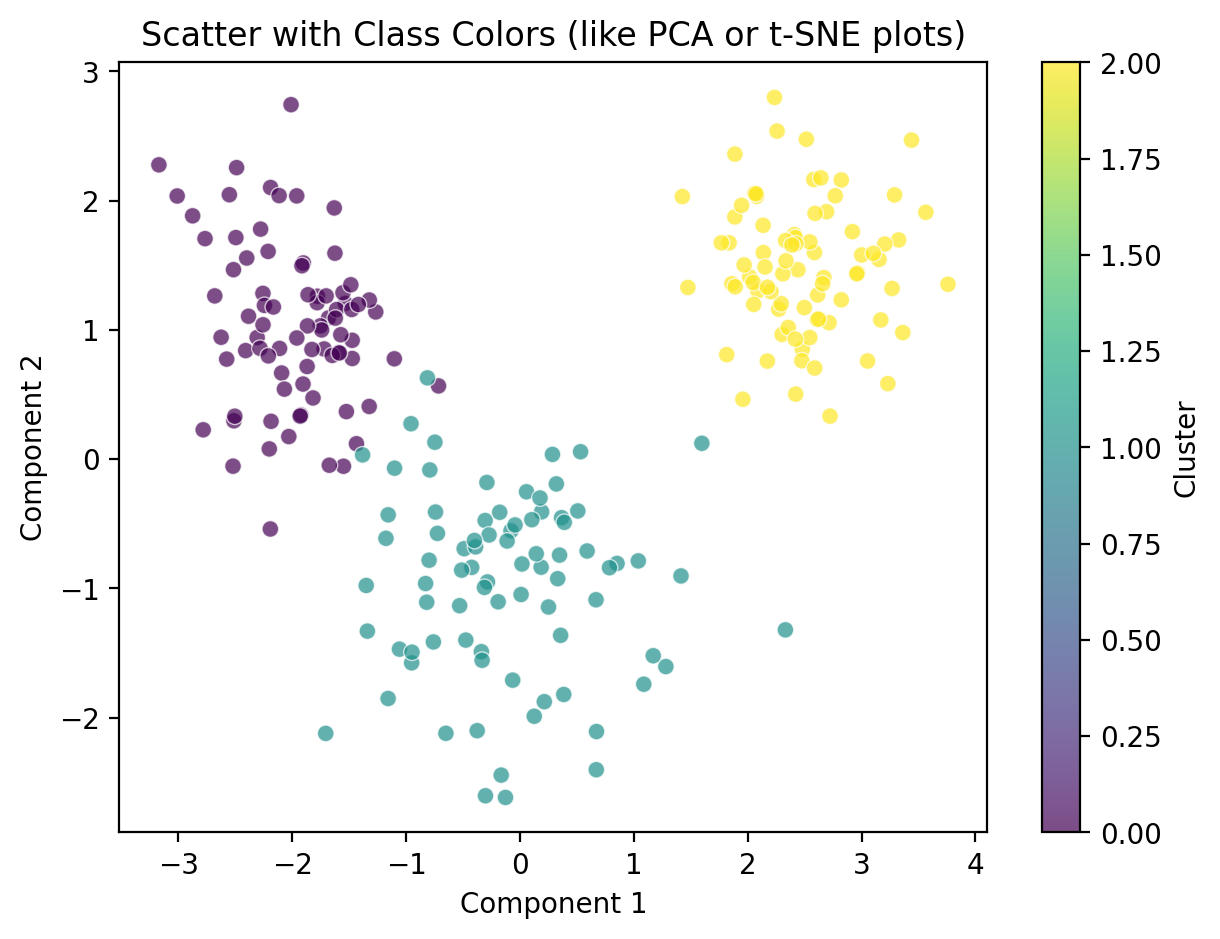

In [7]:
# Scatter with color-coded classes — THE pattern for cluster/classification visualization
rng = np.random.default_rng(42)

# Simulate 3 clusters
n = 80
x = np.concatenate([rng.normal(-2, 0.6, n), rng.normal(0, 0.8, n), rng.normal(2.5, 0.5, n)])
y = np.concatenate([rng.normal(1, 0.6, n),  rng.normal(-1, 0.7, n), rng.normal(1.5, 0.5, n)])
labels = np.array([0]*n + [1]*n + [2]*n)

fig, ax = plt.subplots(figsize=(7, 5))

# c=labels colors each point by its label, cmap picks the color palette
scatter = ax.scatter(x, y, c=labels, cmap='viridis', alpha=0.7, edgecolors='white', linewidth=0.5)

ax.set_title("Scatter with Class Colors (like PCA or t-SNE plots)")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")

# Add a colorbar to show what colors mean
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Cluster")
plt.show()

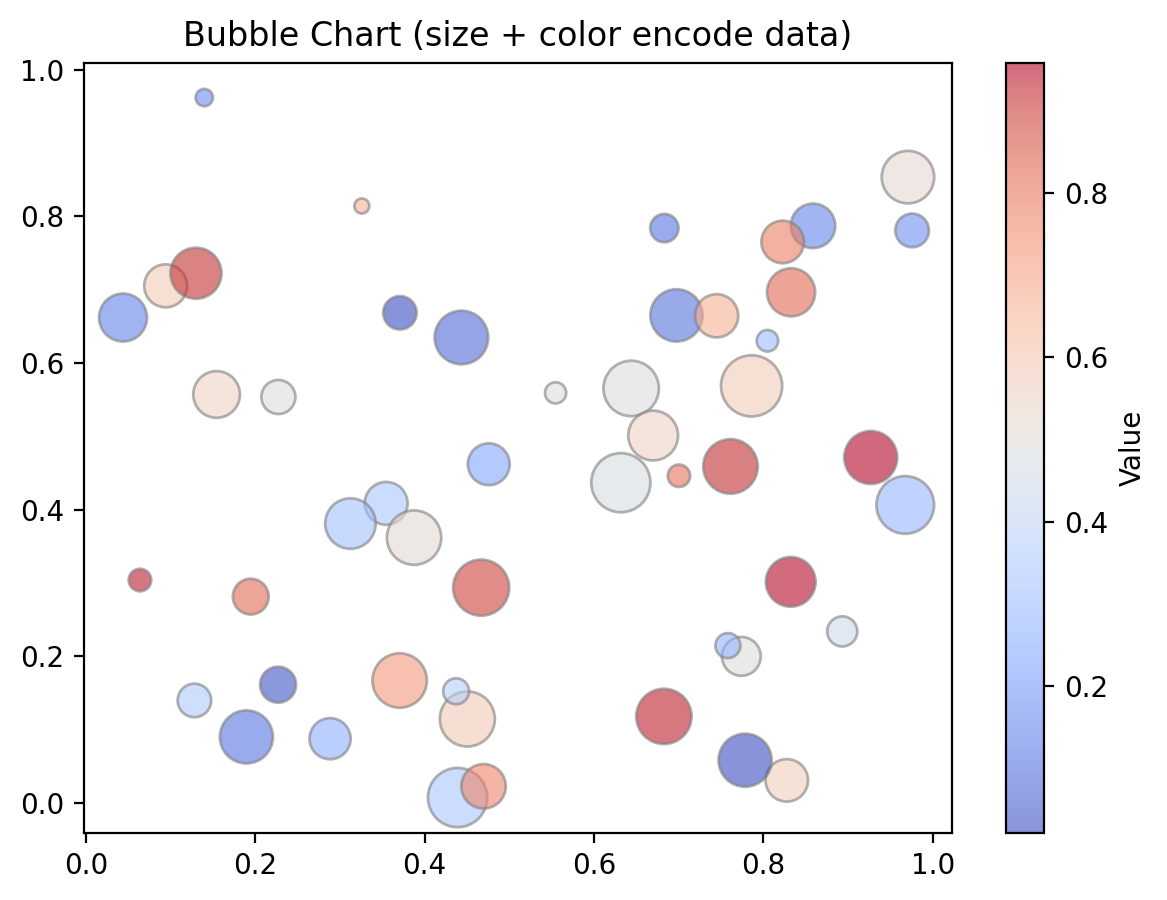

In [8]:
# Scatter with size and color mapped to data — "bubble chart"
# s = size of each point, c = color of each point
rng = np.random.default_rng(42)

n = 50
x = rng.random(n)
y = rng.random(n)
sizes = rng.integers(20, 500, n)      # point sizes
colors = rng.random(n)                 # values to map to colorscale

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(x, y, s=sizes, c=colors, cmap='coolwarm', alpha=0.6, edgecolors='grey')
plt.colorbar(scatter, ax=ax, label='Value')
ax.set_title("Bubble Chart (size + color encode data)")
plt.show()

## 4. Bar Charts

Used for feature importance, class distribution, model comparison, and categorical data.

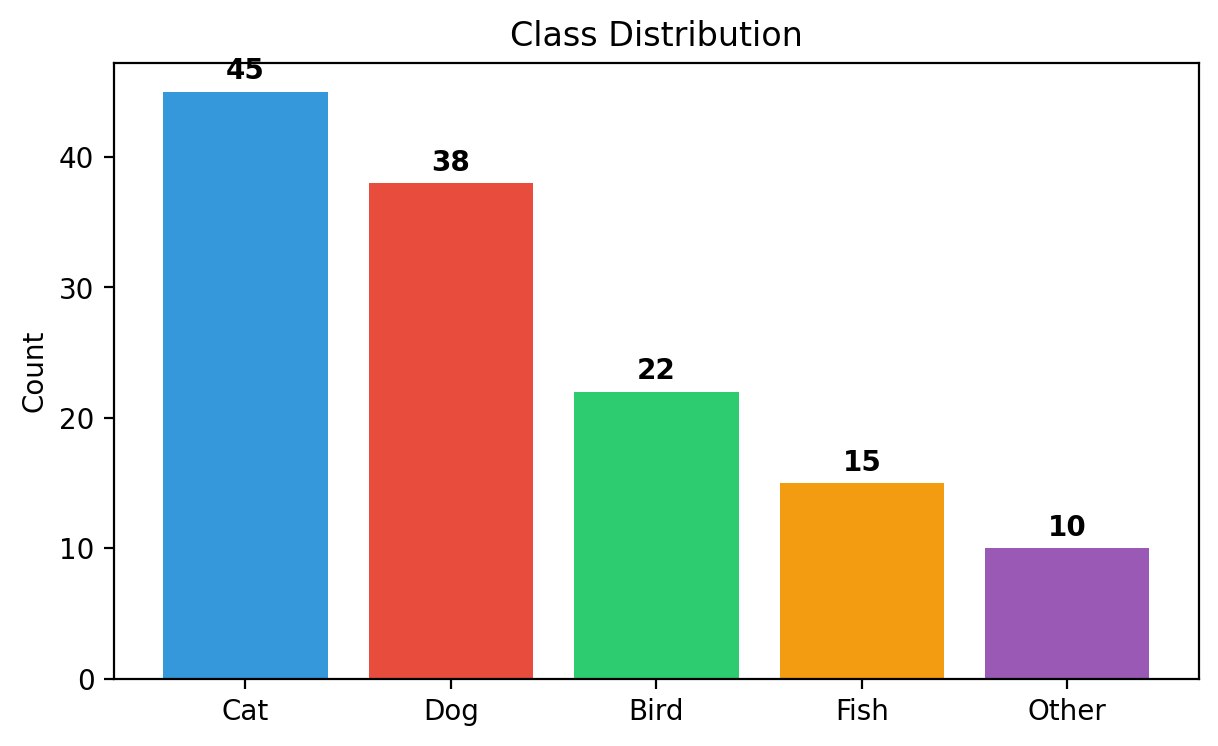

In [9]:
# Vertical bar chart — e.g., class distribution
categories = ['Cat', 'Dog', 'Bird', 'Fish', 'Other']
counts = [45, 38, 22, 15, 10]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(categories, counts, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
ax.set_title("Class Distribution")
ax.set_ylabel("Count")

# Add value labels on top of bars — common in presentations
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.show()

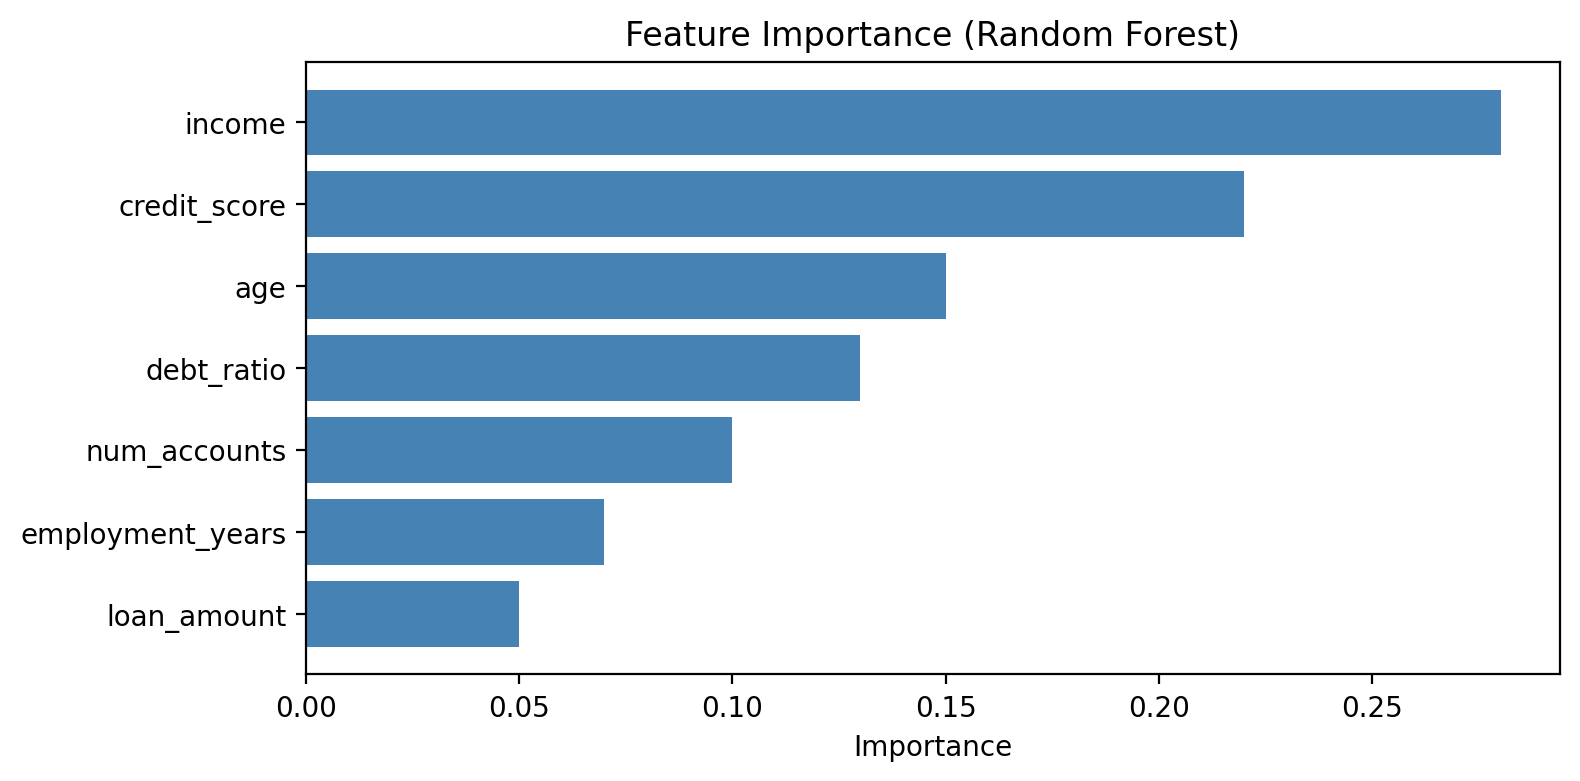

In [10]:
# Horizontal bar chart — better for long category names (e.g., feature importance)
features = ['income', 'credit_score', 'age', 'debt_ratio', 'num_accounts',
            'employment_years', 'loan_amount']
importance = [0.28, 0.22, 0.15, 0.13, 0.10, 0.07, 0.05]

# Sort by importance (common pattern)
sorted_idx = np.argsort(importance)
features_sorted = [features[i] for i in sorted_idx]
importance_sorted = [importance[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(features_sorted, importance_sorted, color='steelblue')
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

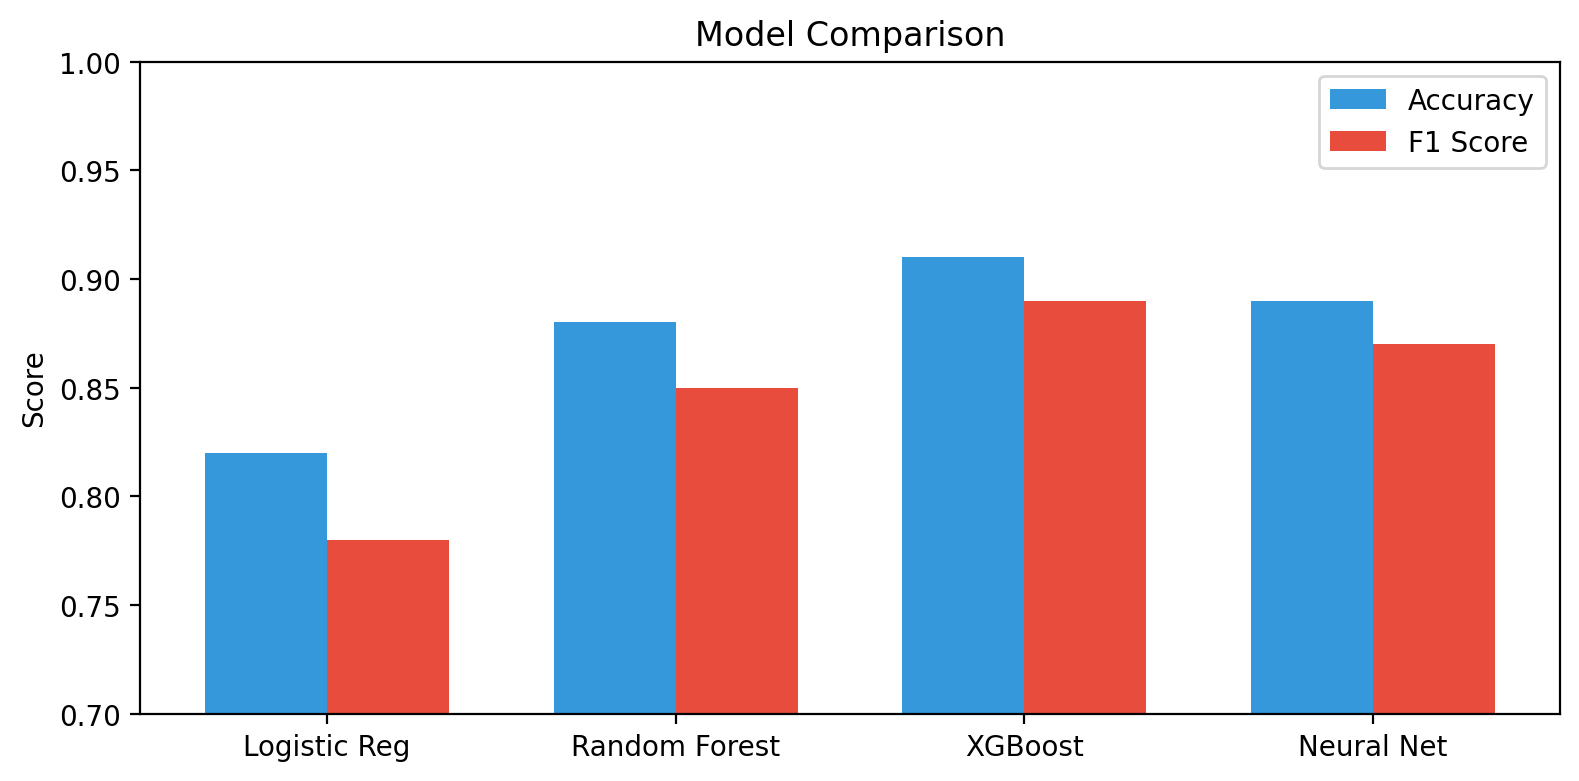

In [11]:
# Grouped bar chart — comparing metrics across models
models = ['Logistic Reg', 'Random Forest', 'XGBoost', 'Neural Net']
accuracy = [0.82, 0.88, 0.91, 0.89]
f1_score = [0.78, 0.85, 0.89, 0.87]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x + width/2, f1_score, width, label='F1 Score', color='#e74c3c')

ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.7, 1.0)  # Zoom in on the relevant range
plt.tight_layout()
plt.show()

## 5. Histograms

Essential for understanding data distributions — the first thing you plot in EDA (Exploratory Data Analysis).

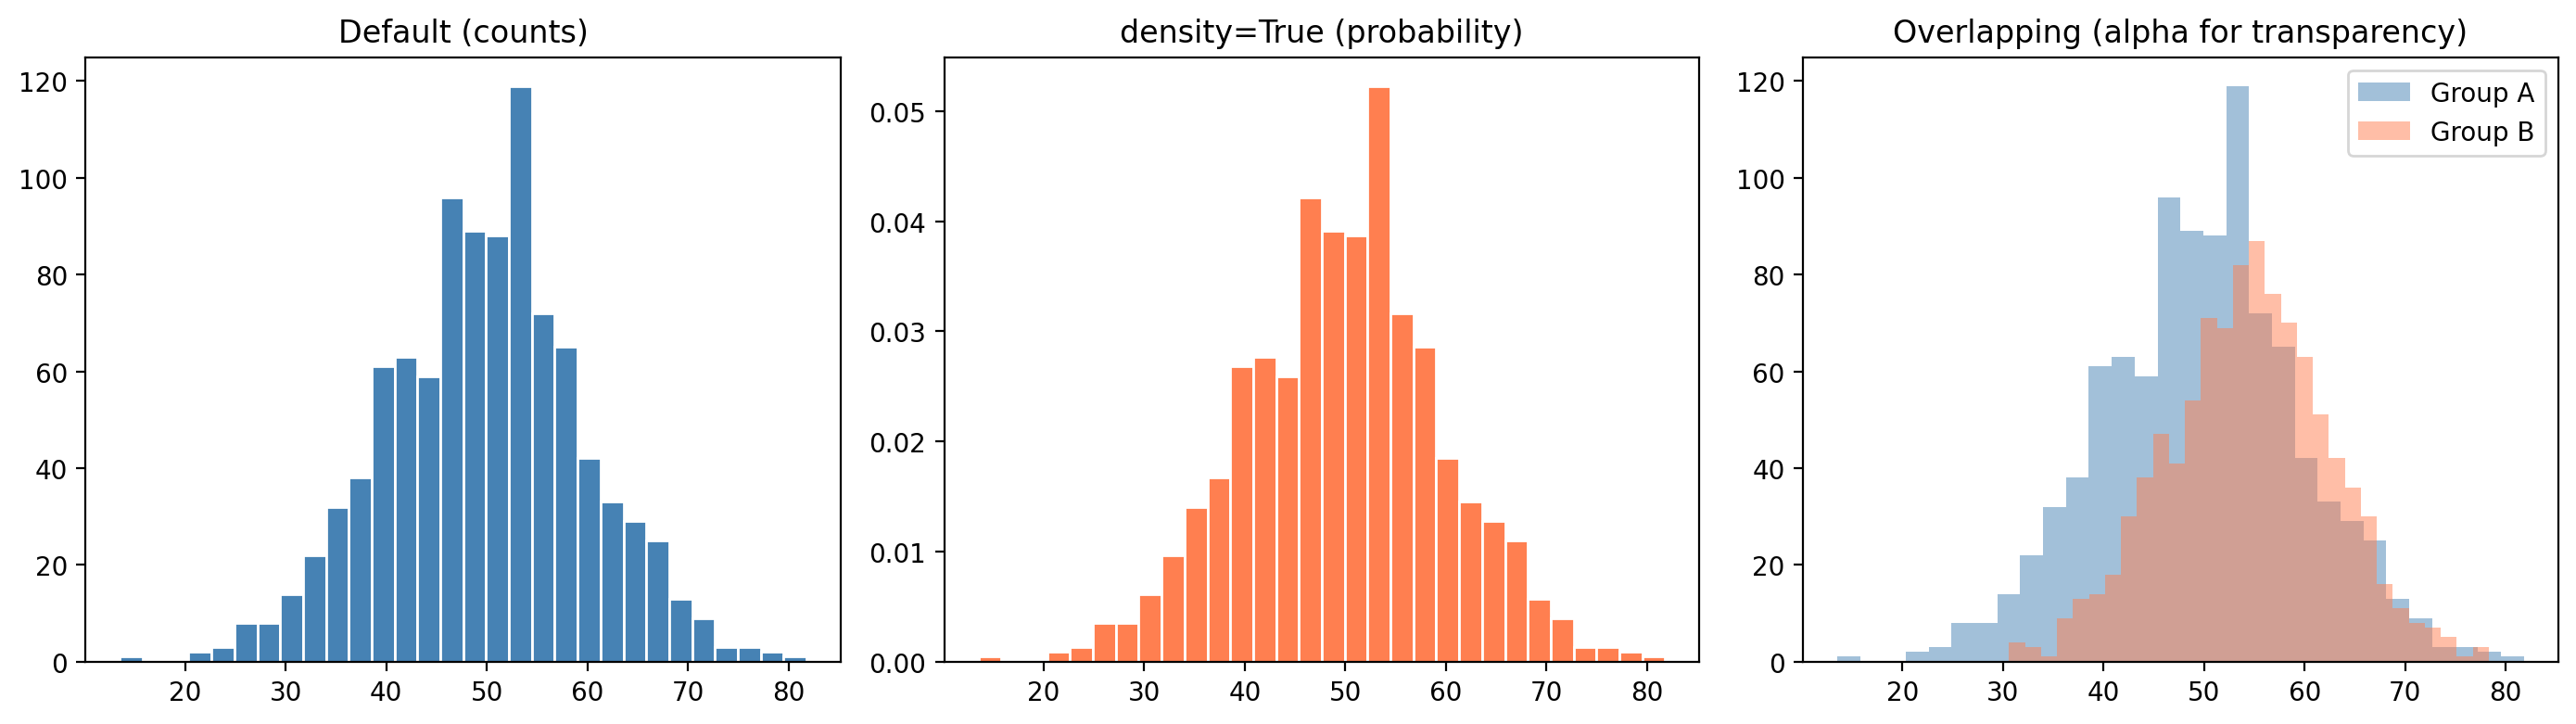

In [12]:
# Basic histogram
rng = np.random.default_rng(42)
data = rng.normal(loc=50, scale=10, size=1000)  # 1000 samples from N(50, 10)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Default
axes[0].hist(data, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Default (counts)")

# Density (area sums to 1) — useful for comparing distributions
axes[1].hist(data, bins=30, density=True, color='coral', edgecolor='white')
axes[1].set_title("density=True (probability)")

# Overlapping histograms — comparing distributions
data2 = rng.normal(loc=55, scale=8, size=1000)
axes[2].hist(data, bins=30, alpha=0.5, label='Group A', color='steelblue')
axes[2].hist(data2, bins=30, alpha=0.5, label='Group B', color='coral')
axes[2].legend()
axes[2].set_title("Overlapping (alpha for transparency)")

plt.tight_layout()
plt.show()

## 6. Subplots — Multiple Plots in One Figure

The `plt.subplots(rows, cols)` pattern is everywhere in ML code — comparing features, showing train vs test, etc.

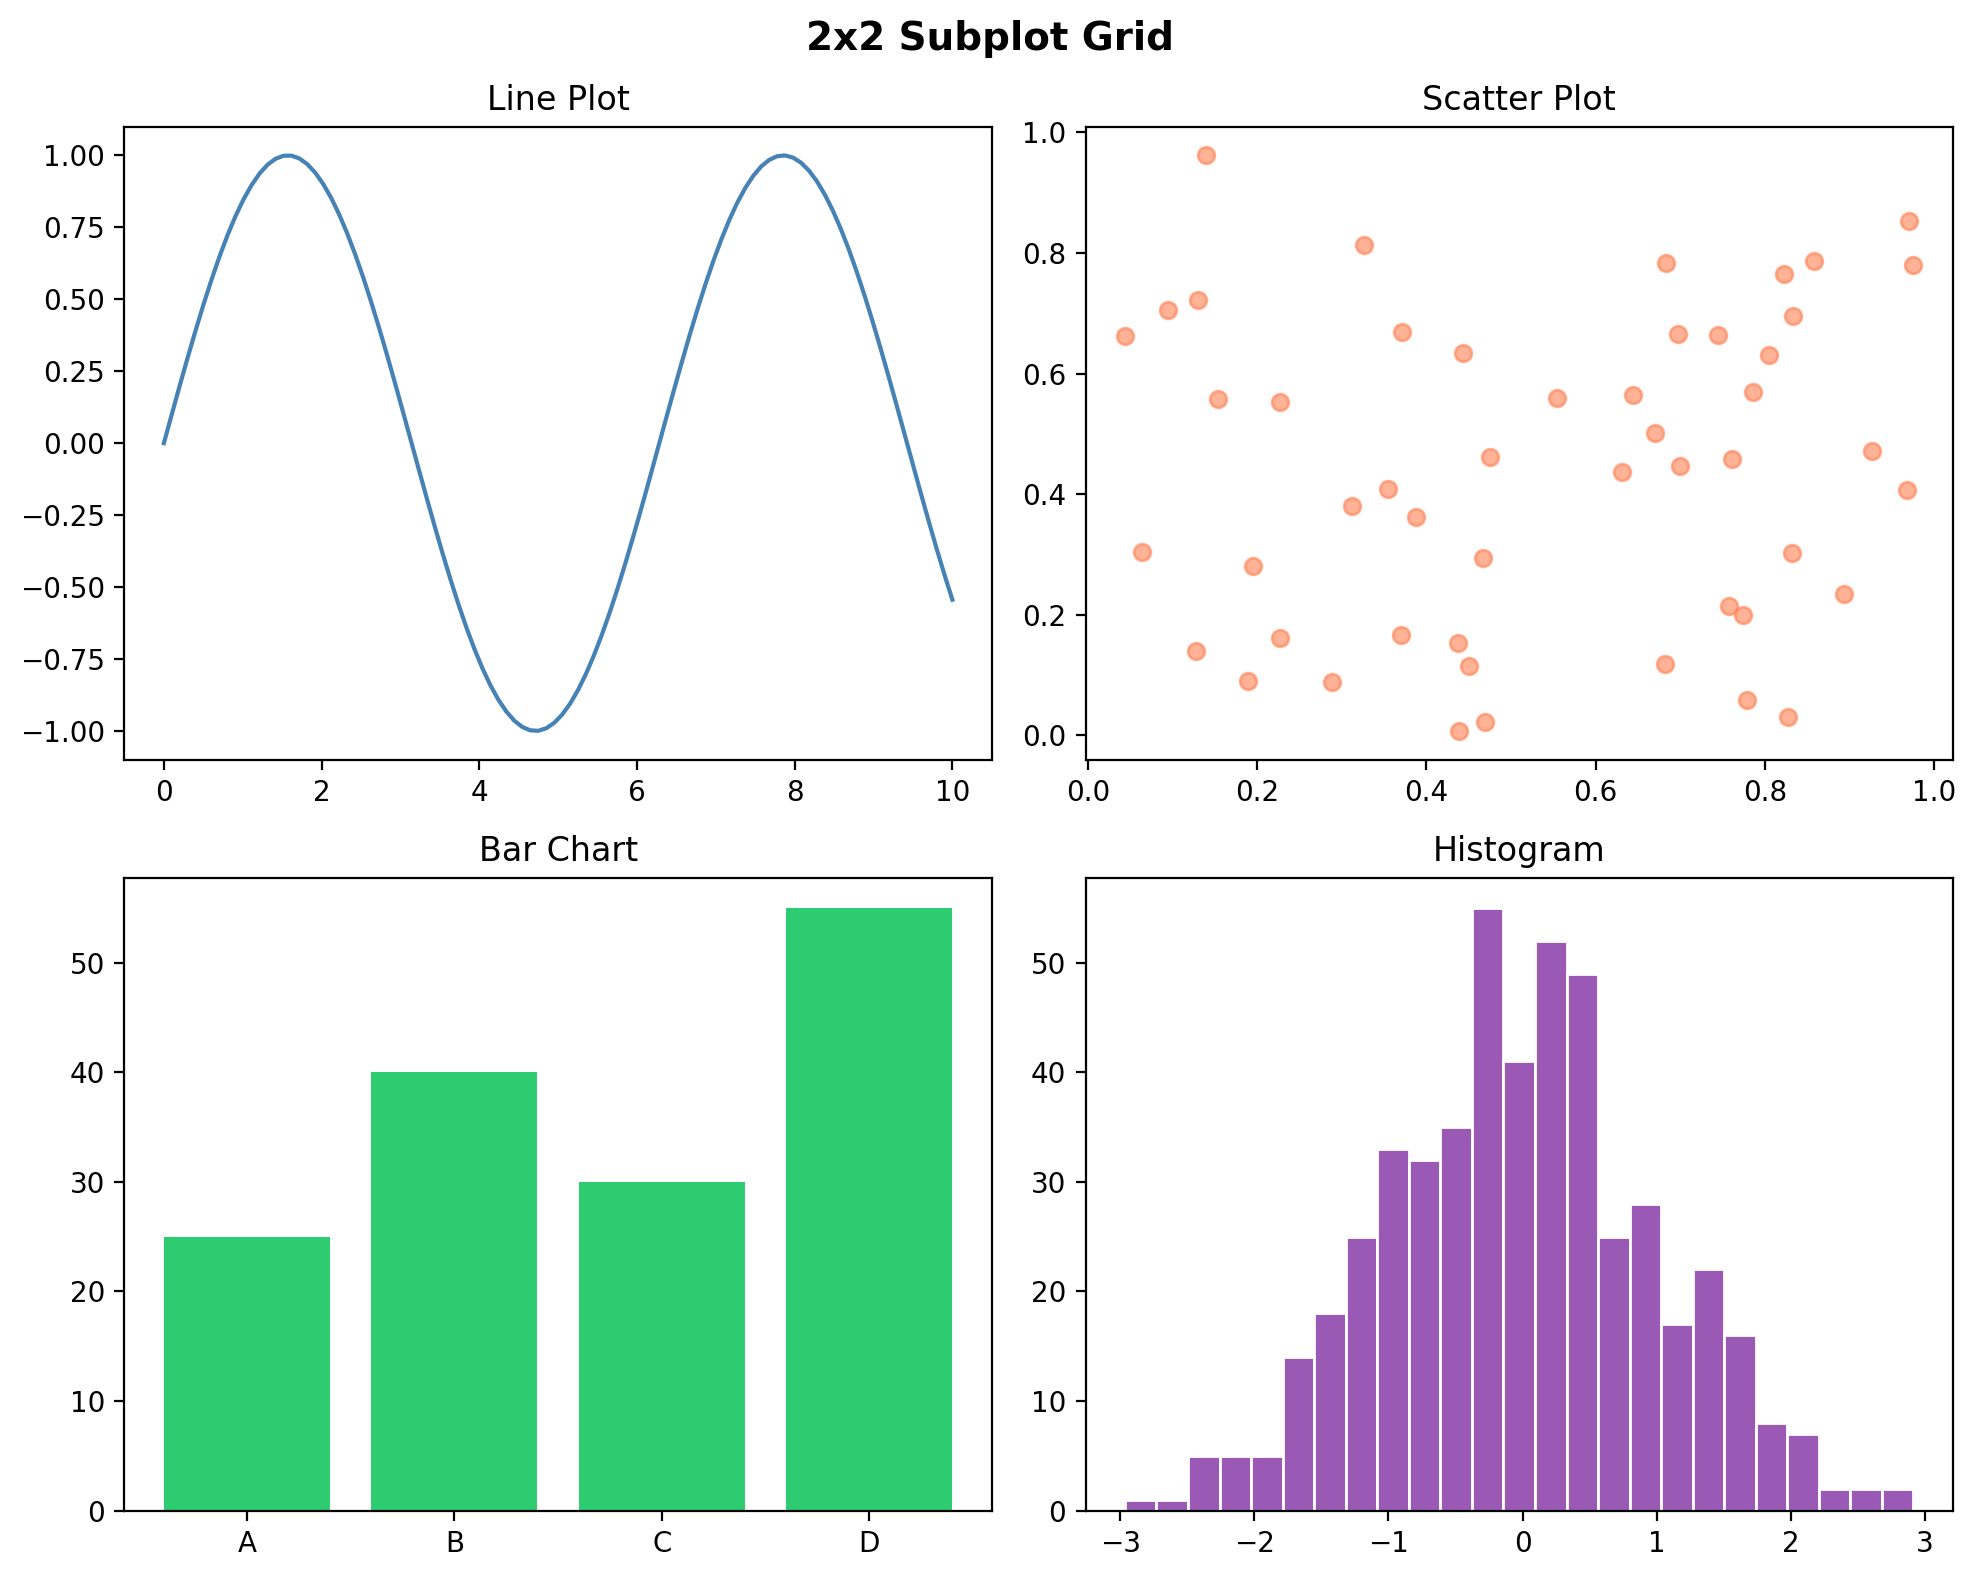

In [13]:
# 2x2 grid of subplots
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# axes is now a 2D array: axes[row, col]

# Top-left: line plot
x = np.linspace(0, 10, 100)
axes[0, 0].plot(x, np.sin(x), color='steelblue')
axes[0, 0].set_title("Line Plot")

# Top-right: scatter
axes[0, 1].scatter(rng.random(50), rng.random(50), alpha=0.6, color='coral')
axes[0, 1].set_title("Scatter Plot")

# Bottom-left: bar
axes[1, 0].bar(['A', 'B', 'C', 'D'], [25, 40, 30, 55], color='#2ecc71')
axes[1, 0].set_title("Bar Chart")

# Bottom-right: histogram
axes[1, 1].hist(rng.normal(0, 1, 500), bins=25, color='#9b59b6', edgecolor='white')
axes[1, 1].set_title("Histogram")

# fig.suptitle adds a title above ALL subplots
fig.suptitle("2x2 Subplot Grid", fontsize=14, fontweight='bold')
plt.tight_layout()  # Prevents overlapping labels
plt.show()

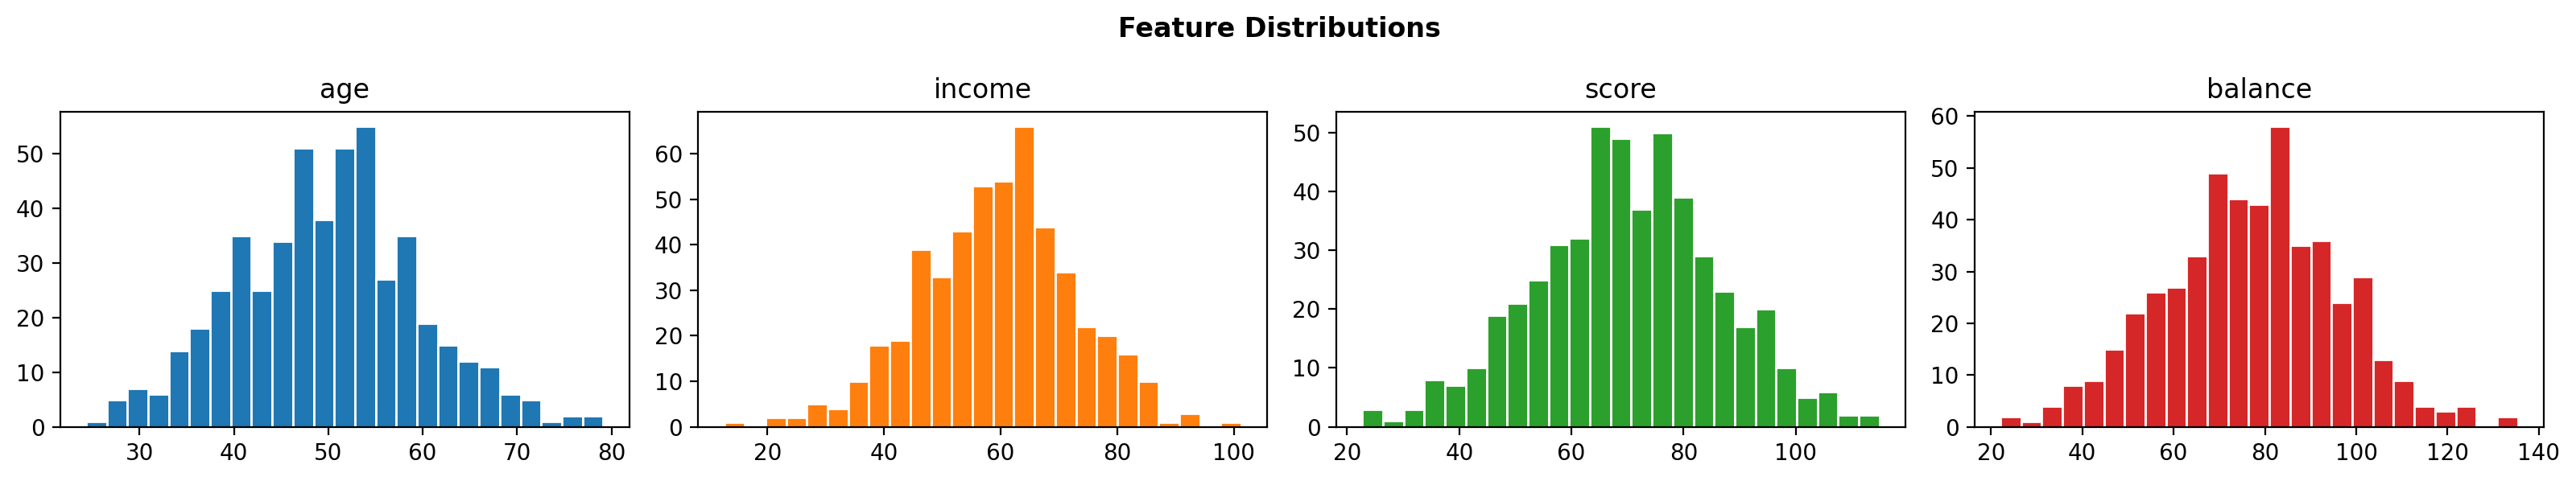

In [14]:
# 1xN row of subplots — common for comparing features
# When nrows or ncols is 1, axes is a 1D array

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

rng = np.random.default_rng(42)
feature_names = ['age', 'income', 'score', 'balance']
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    data = rng.normal(loc=50+i*10, scale=10+i*3, size=500)
    ax.hist(data, bins=25, color=f'C{i}', edgecolor='white')
    ax.set_title(name)

plt.suptitle("Feature Distributions", fontweight='bold')
plt.tight_layout()
plt.show()

# Iterating over axes with zip() is the standard ML pattern
# axes.flat also works for 2D grids: for ax in axes.flat:

## 7. Customization Deep Dive

Labels, legends, ticks, colors, annotations, and styles — the things that turn a quick plot into a readable figure.

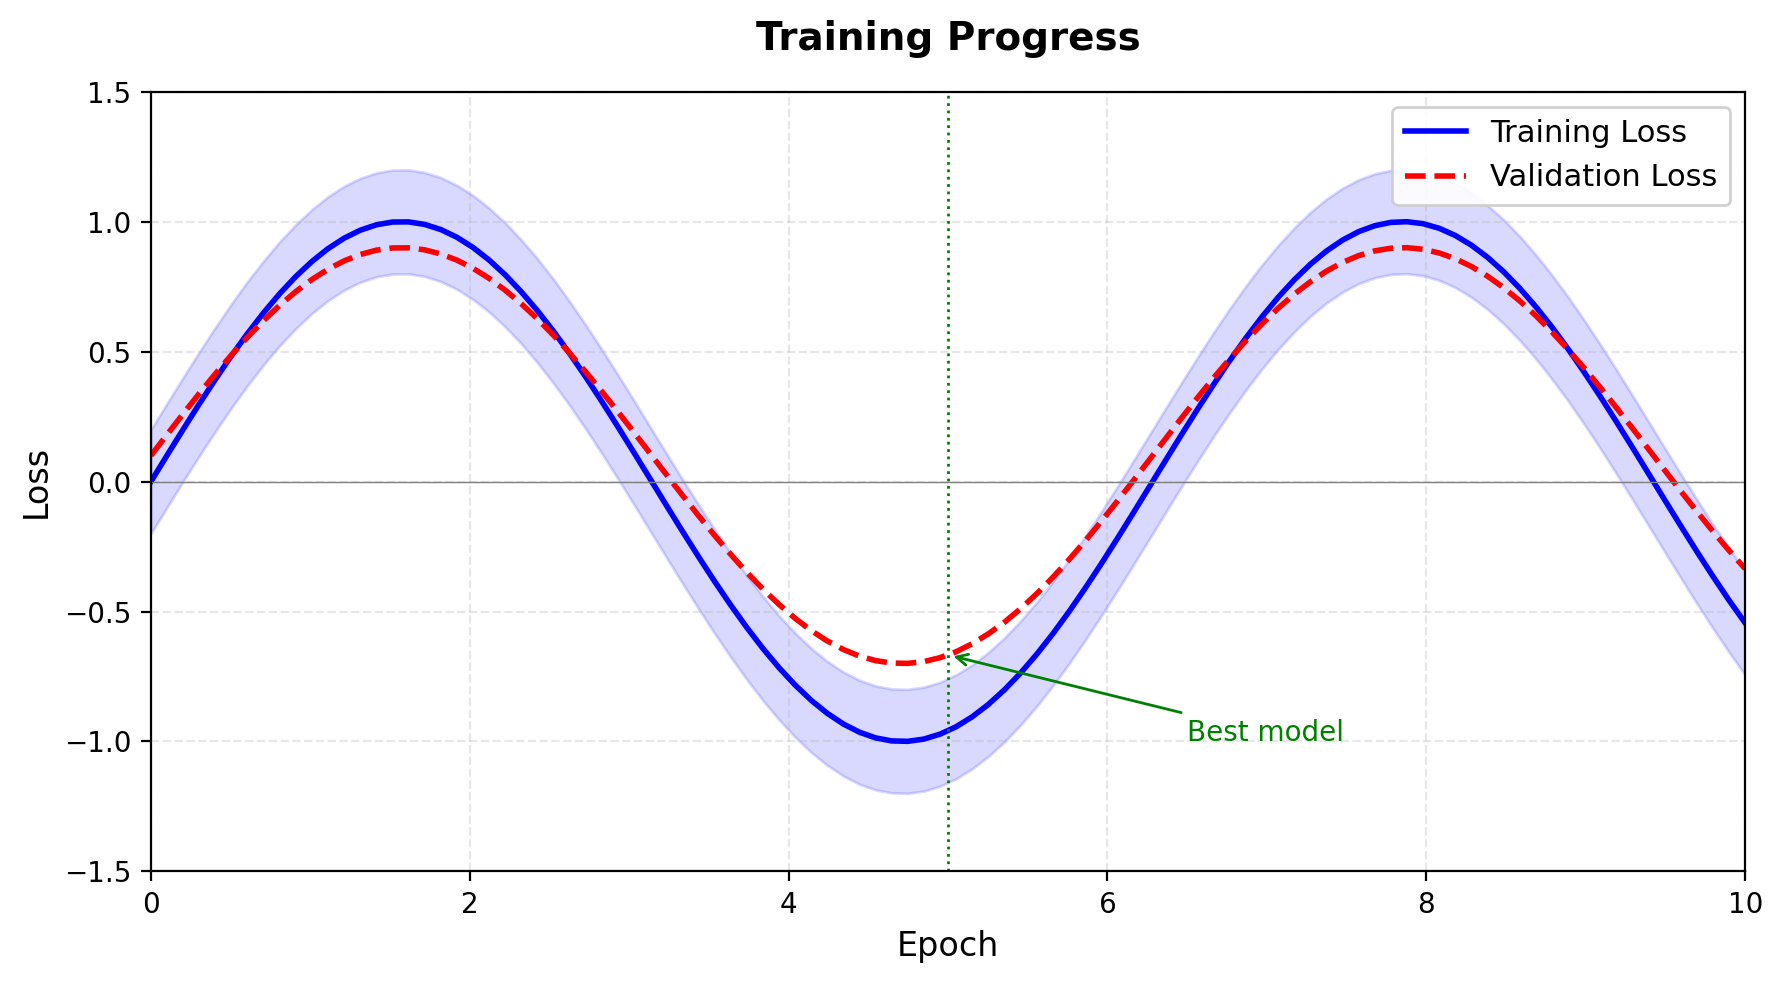

In [15]:
# Comprehensive customization example
x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, np.sin(x), 'b-', linewidth=2, label='Training Loss')
ax.plot(x, np.sin(x) * 0.8 + 0.1, 'r--', linewidth=2, label='Validation Loss')

# Title and labels with font control
ax.set_title("Training Progress", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)

# Axis limits and ticks
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)
ax.set_xticks(np.arange(0, 11, 2))  # Custom tick positions

# Legend positioning
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Grid
ax.grid(True, linestyle='--', alpha=0.3)

# Horizontal/vertical reference lines
ax.axhline(y=0, color='grey', linestyle='-', linewidth=0.5)  # horizontal line at y=0
ax.axvline(x=5, color='green', linestyle=':', linewidth=1, label='Best epoch')  # vertical

# Annotation — point to something specific
ax.annotate('Best model', xy=(5, np.sin(5)*0.8+0.1), xytext=(6.5, -1),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='green'),
            color='green')

# Fill between (e.g., confidence interval)
ax.fill_between(x, np.sin(x) - 0.2, np.sin(x) + 0.2, alpha=0.15, color='blue')

plt.tight_layout()
plt.show()

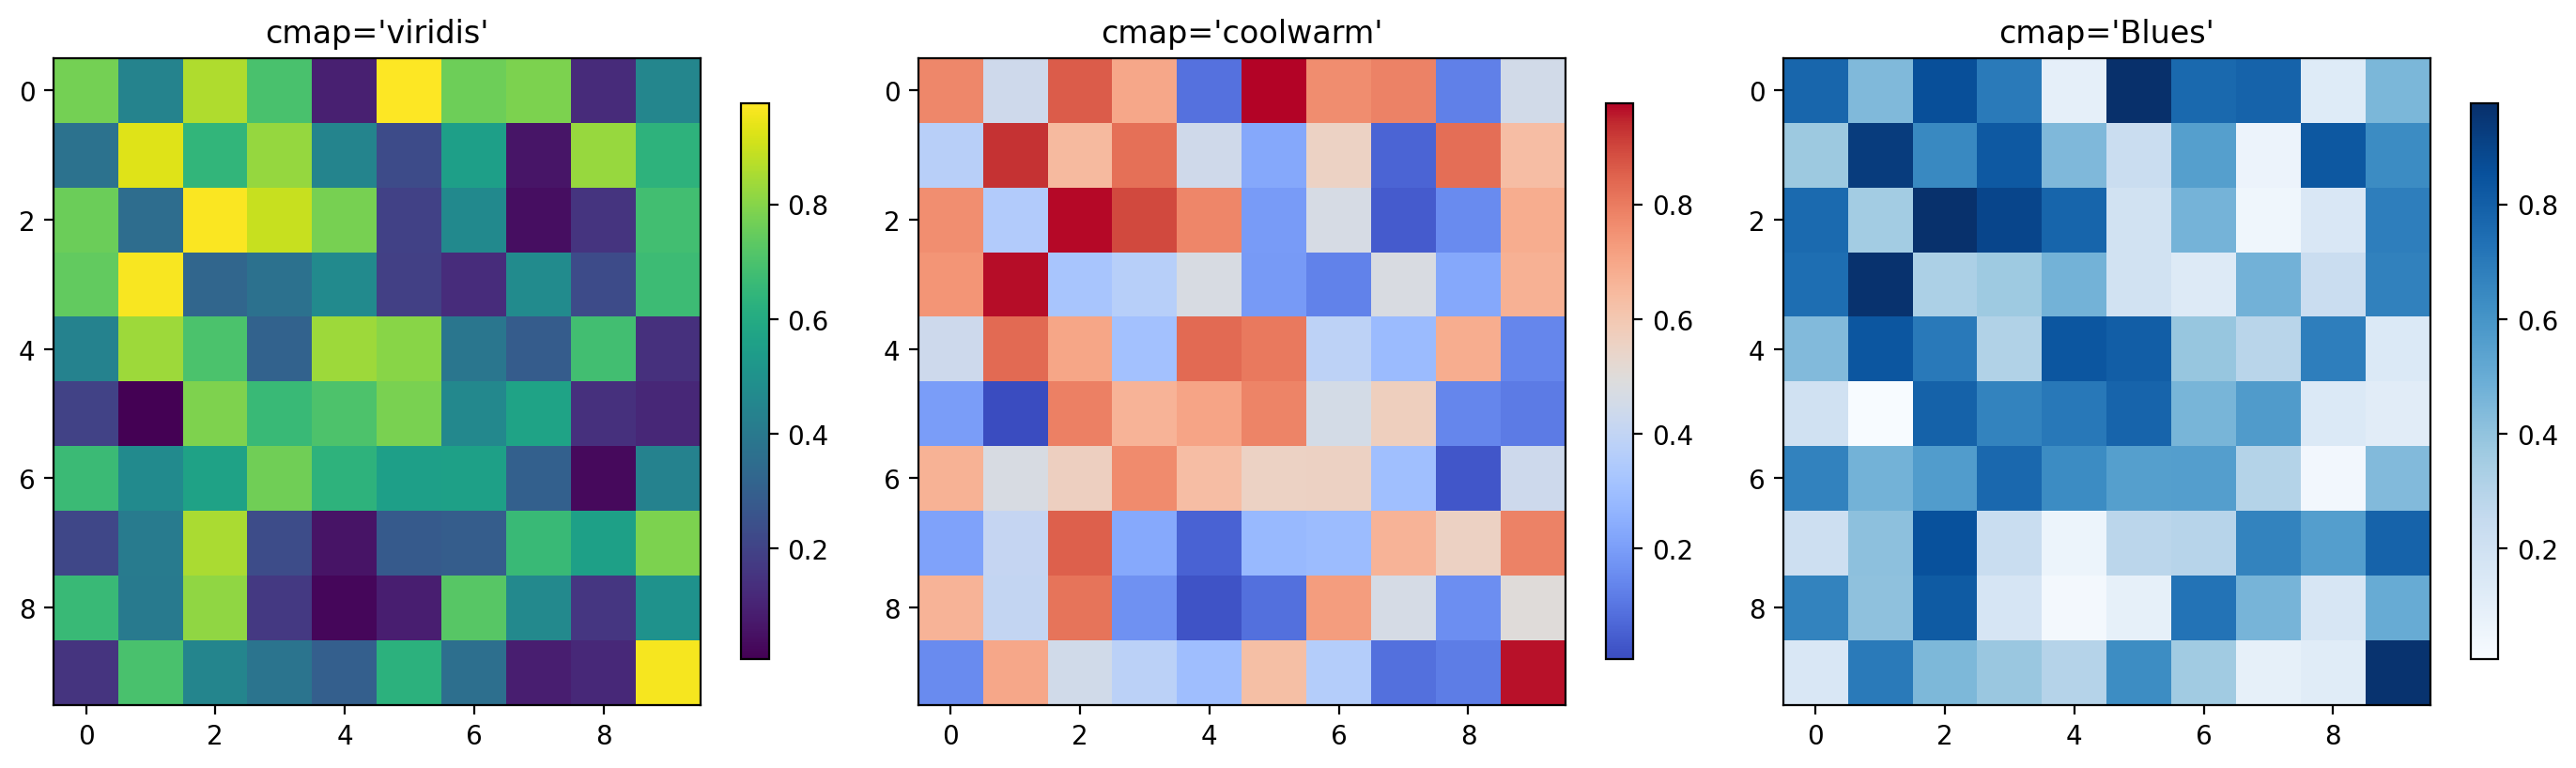

In [16]:
# Colormaps — you'll see cmap='...' everywhere in ML plotting
# Common colormaps in ML:
#   Sequential:  'viridis' (default), 'Blues', 'Reds', 'YlOrRd'
#   Diverging:   'coolwarm', 'RdBu', 'seismic' (for pos/neg values)
#   Categorical: 'Set1', 'Set2', 'tab10', 'tab20'

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

rng = np.random.default_rng(42)
data = rng.random((10, 10))

for ax, cmap in zip(axes, ['viridis', 'coolwarm', 'Blues']):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(f"cmap='{cmap}'")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot'] ...


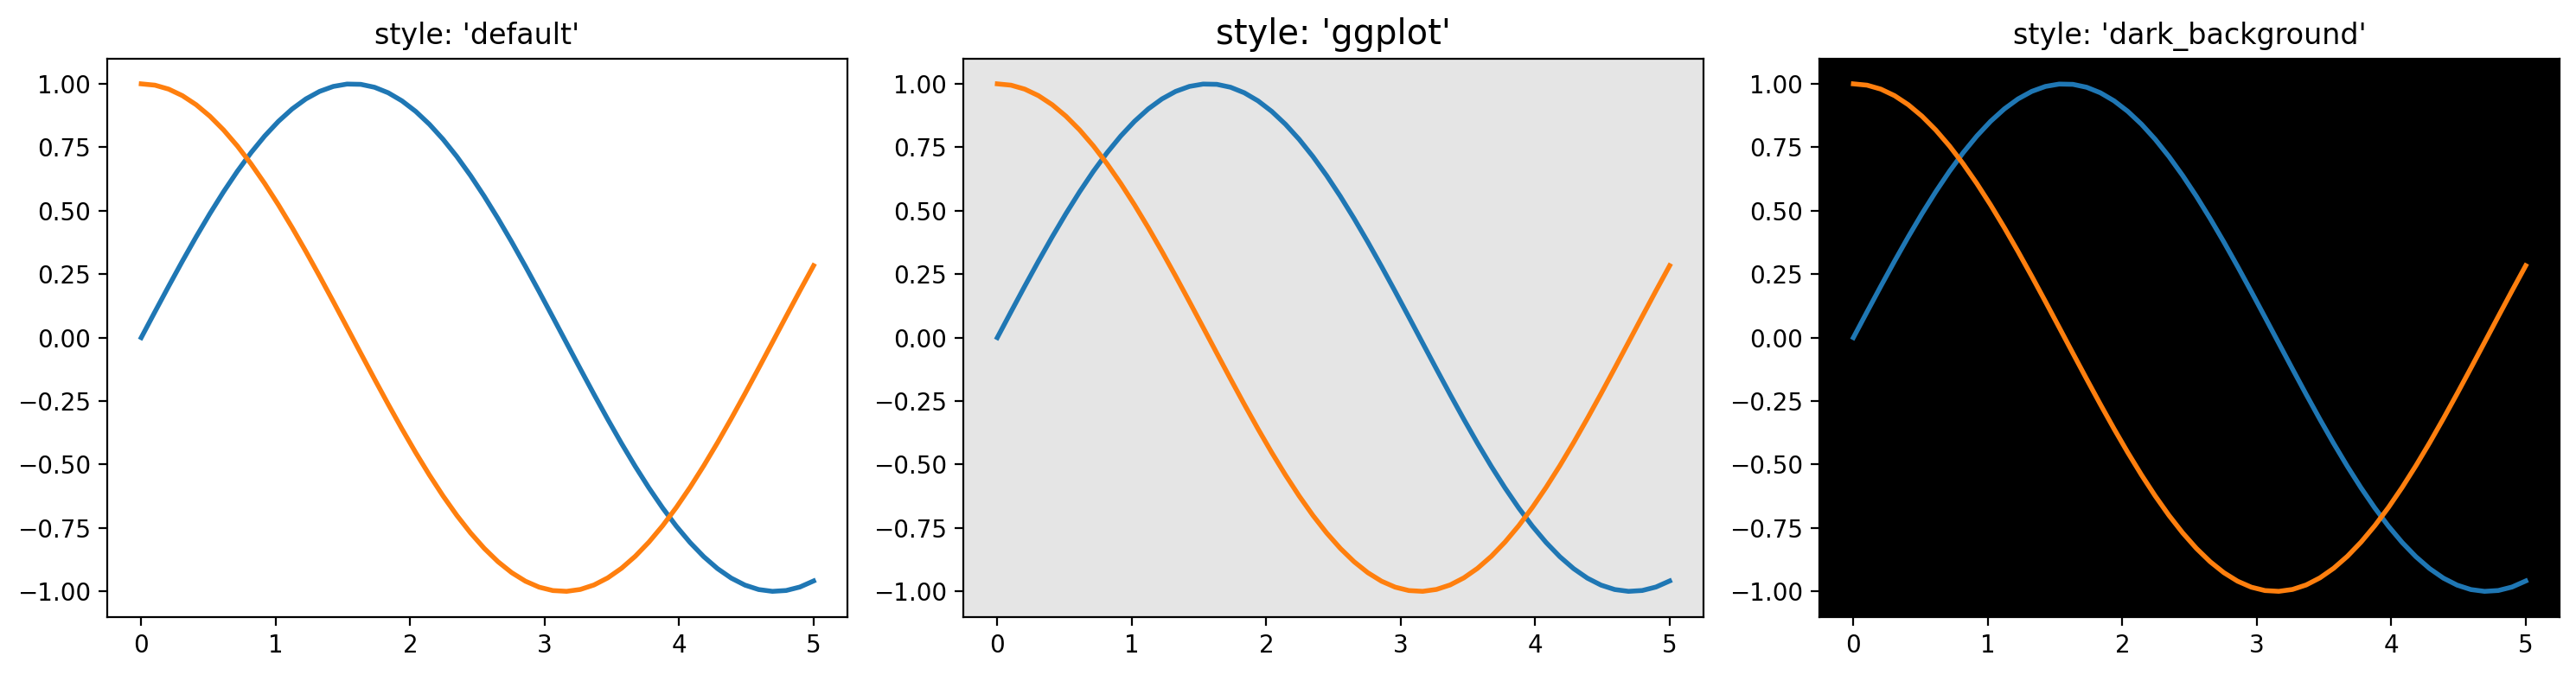

In [17]:
# Style sheets — change the overall look with one line
# You'll see plt.style.use() at the top of many ML notebooks

print("Available styles:", plt.style.available[:10], "...")

# Common choices in ML code:
# 'seaborn-v0_8' or 'seaborn-v0_8-whitegrid' — clean, professional
# 'ggplot'        — R-style
# 'dark_background' — for presentations
# 'default'       — reset to default

# Demo a few styles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.linspace(0, 5, 50)

for ax, style_name in zip(axes, ['default', 'ggplot', 'dark_background']):
    with plt.style.context(style_name):  # Temporary style (does not affect other plots)
        ax.plot(x, np.sin(x), linewidth=2)
        ax.plot(x, np.cos(x), linewidth=2)
        ax.set_title(f"style: '{style_name}'")
        ax.set_facecolor(plt.rcParams['axes.facecolor'])  # needed for inline context

plt.tight_layout()
plt.show()

## 8. Heatmaps

Used for confusion matrices, correlation matrices, and attention weights — all critical in ML.

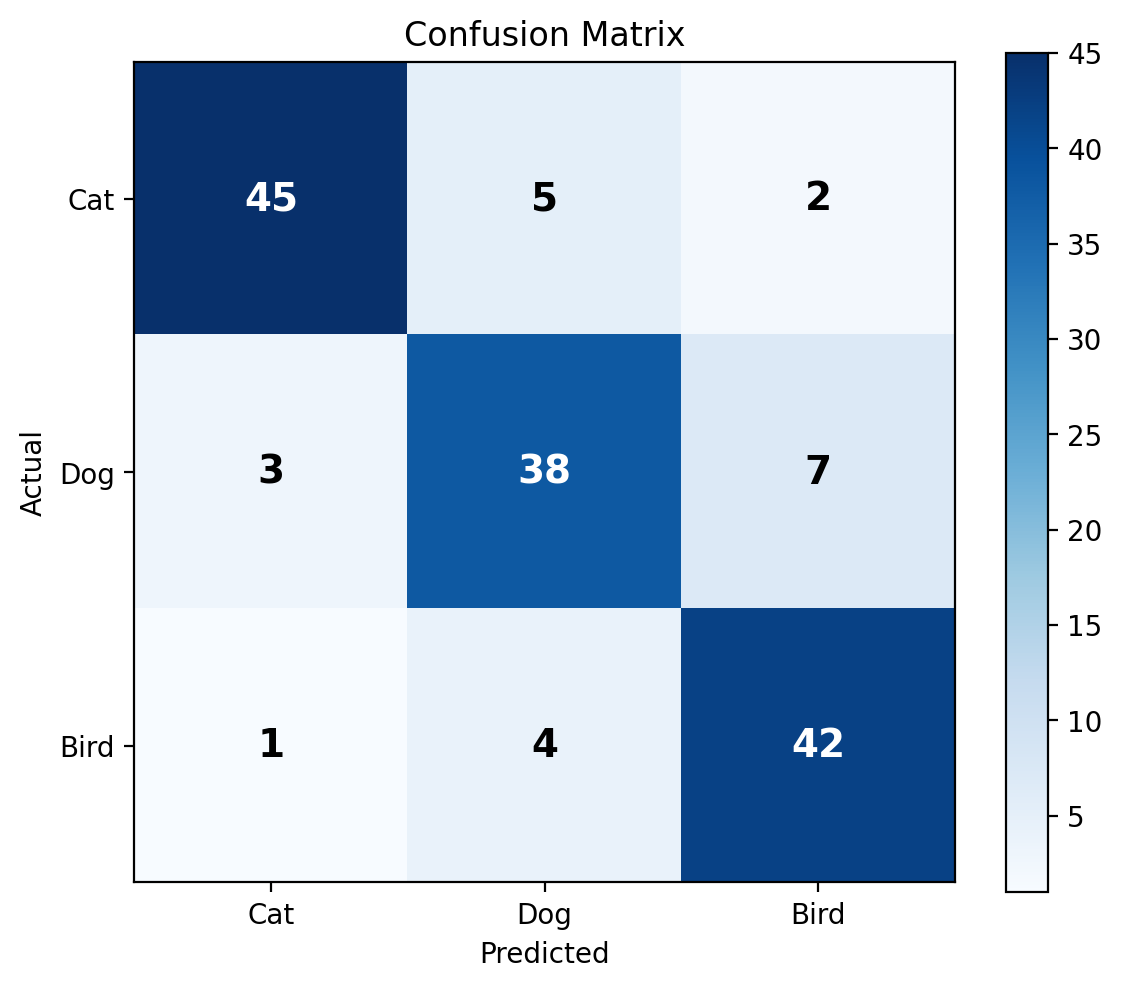

In [18]:
# imshow — the base function for heatmaps
# Confusion matrix — you'll see this in EVERY classification project

confusion = np.array([[45, 5, 2],
                      [3, 38, 7],
                      [1, 4, 42]])
class_names = ['Cat', 'Dog', 'Bird']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion, cmap='Blues')

# Add text annotations in each cell
for i in range(len(class_names)):
    for j in range(len(class_names)):
        color = 'white' if confusion[i, j] > confusion.max() / 2 else 'black'
        ax.text(j, i, str(confusion[i, j]), ha='center', va='center',
                color=color, fontsize=14, fontweight='bold')

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

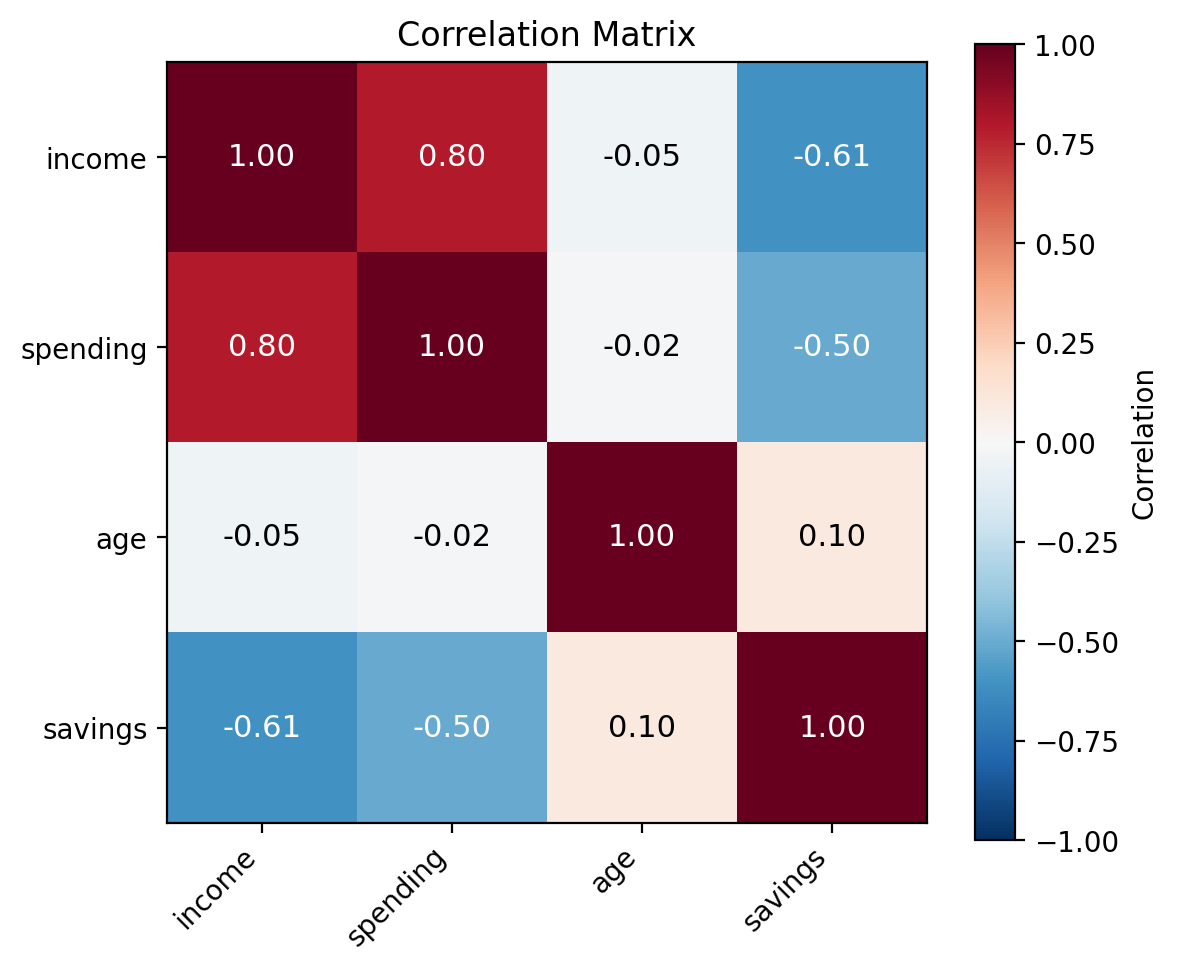

In [19]:
# Correlation matrix heatmap — standard EDA step
rng = np.random.default_rng(42)

# Simulate correlated features
n = 200
feature_a = rng.normal(0, 1, n)
feature_b = feature_a * 0.8 + rng.normal(0, 0.5, n)
feature_c = rng.normal(0, 1, n)
feature_d = -feature_a * 0.6 + rng.normal(0, 0.7, n)

data = np.column_stack([feature_a, feature_b, feature_c, feature_d])
names = ['income', 'spending', 'age', 'savings']

# Compute correlation matrix
corr = np.corrcoef(data.T)  # .T because corrcoef expects features as rows

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)  # RdBu_r: red=positive, blue=negative

# Annotate
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                fontsize=11, color='white' if abs(corr[i,j]) > 0.5 else 'black')

ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_yticklabels(names)
ax.set_title("Correlation Matrix")
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

## 9. Box and Violin Plots

Compare distributions across groups — e.g., feature values per class, or model performance across folds.

C:\Users\Windows11\AppData\Local\Temp\ipykernel_2484\3410063583.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(scores, labels=model_names, patch_artist=True)


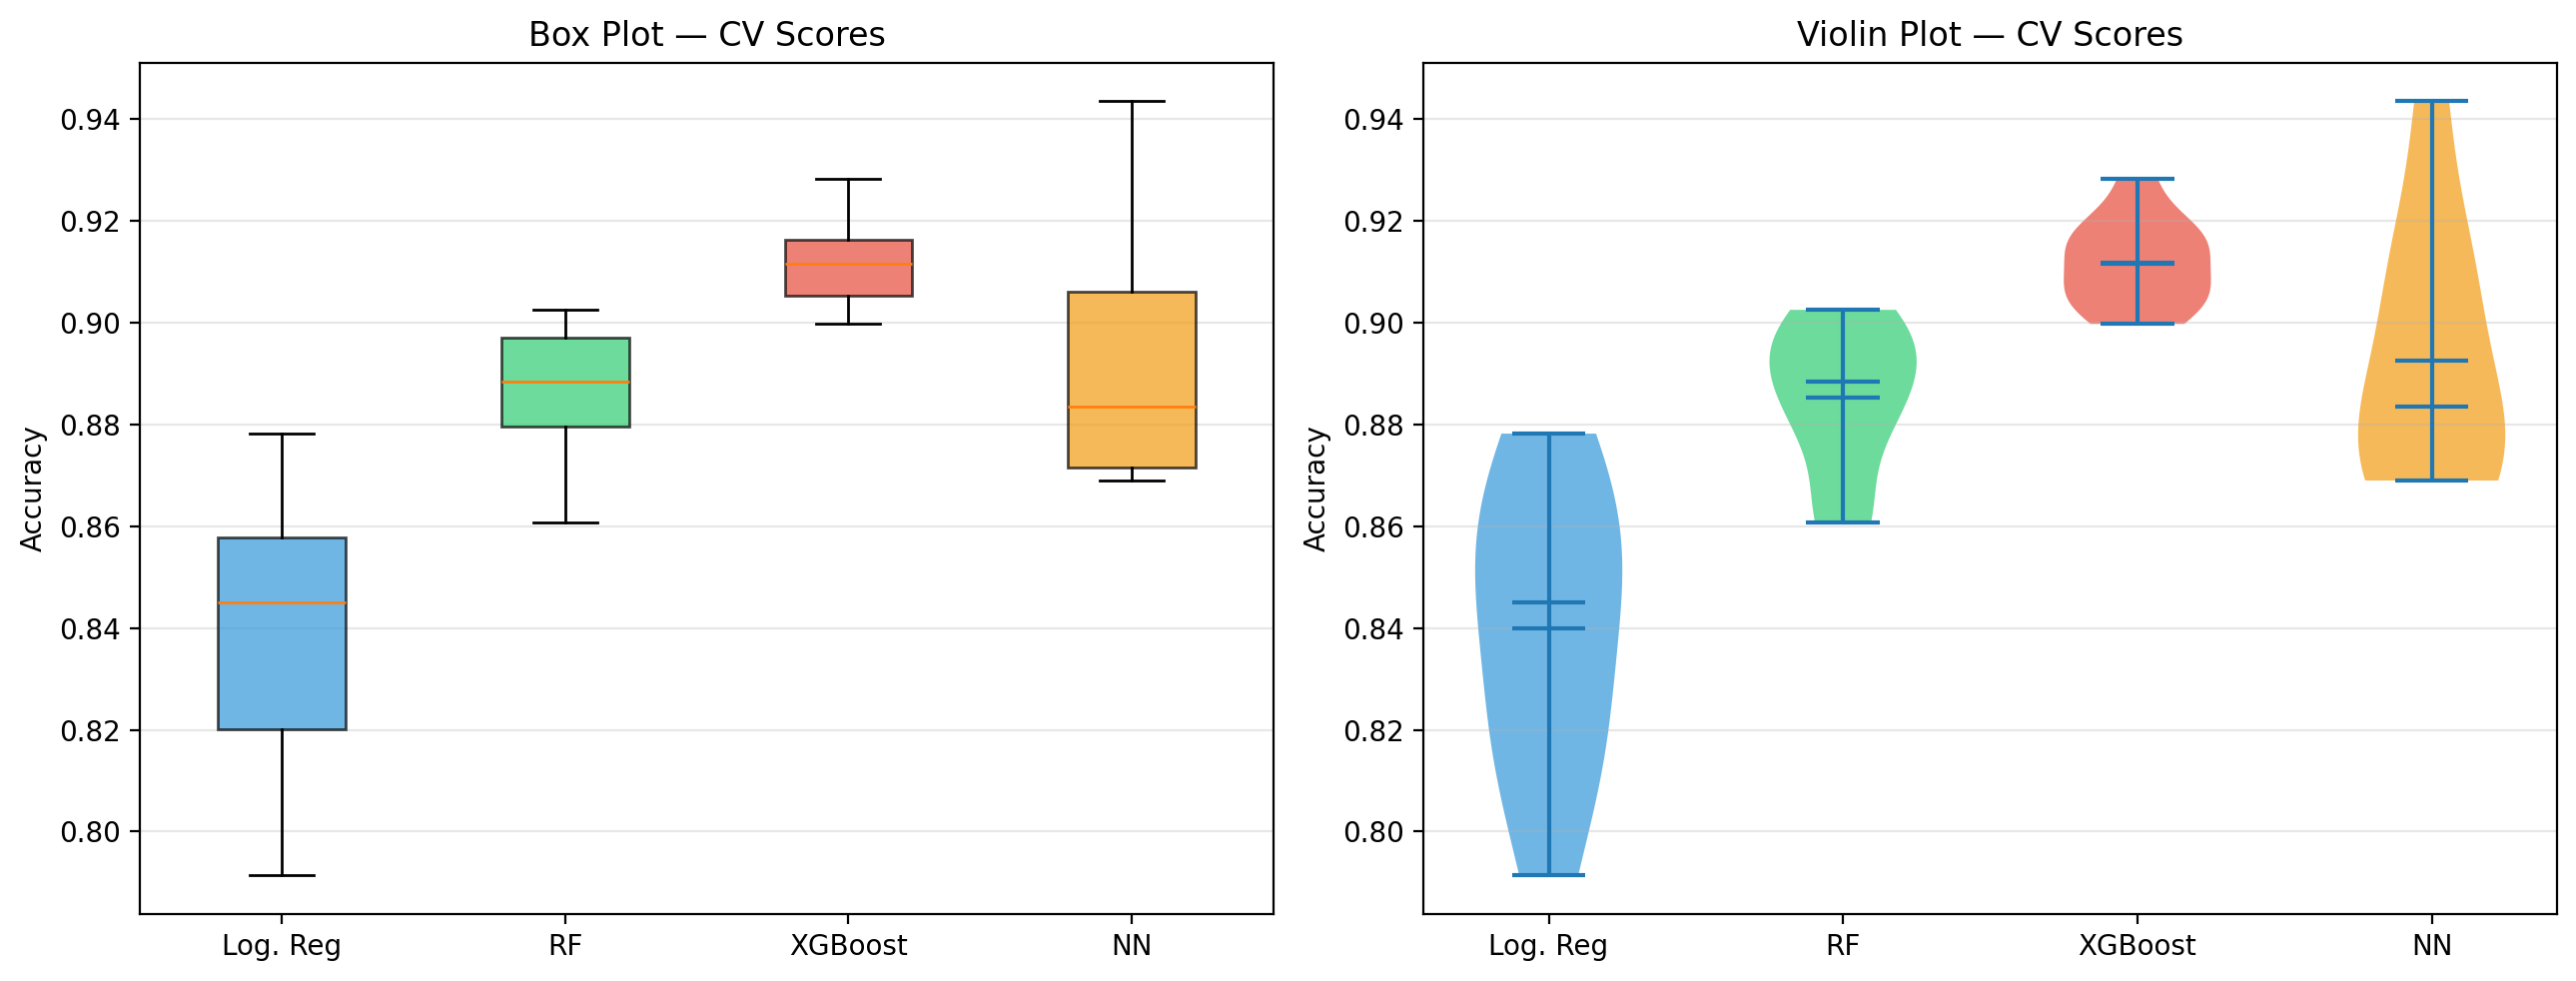

In [20]:
# Box plot — shows median, quartiles, and outliers
rng = np.random.default_rng(42)

# Simulate cross-validation scores for 4 models
scores = [
    rng.normal(0.85, 0.03, 10),  # Logistic Regression
    rng.normal(0.88, 0.02, 10),  # Random Forest
    rng.normal(0.91, 0.015, 10), # XGBoost
    rng.normal(0.89, 0.025, 10), # Neural Net
]
model_names = ['Log. Reg', 'RF', 'XGBoost', 'NN']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
bp = axes[0].boxplot(scores, labels=model_names, patch_artist=True)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Box Plot — CV Scores")
axes[0].grid(axis='y', alpha=0.3)

# Violin plot — shows full distribution shape
vp = axes[1].violinplot(scores, showmeans=True, showmedians=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Violin Plot — CV Scores")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Pie Charts, Log Scales, and Twin Axes

Less common but you'll still encounter these in ML code.

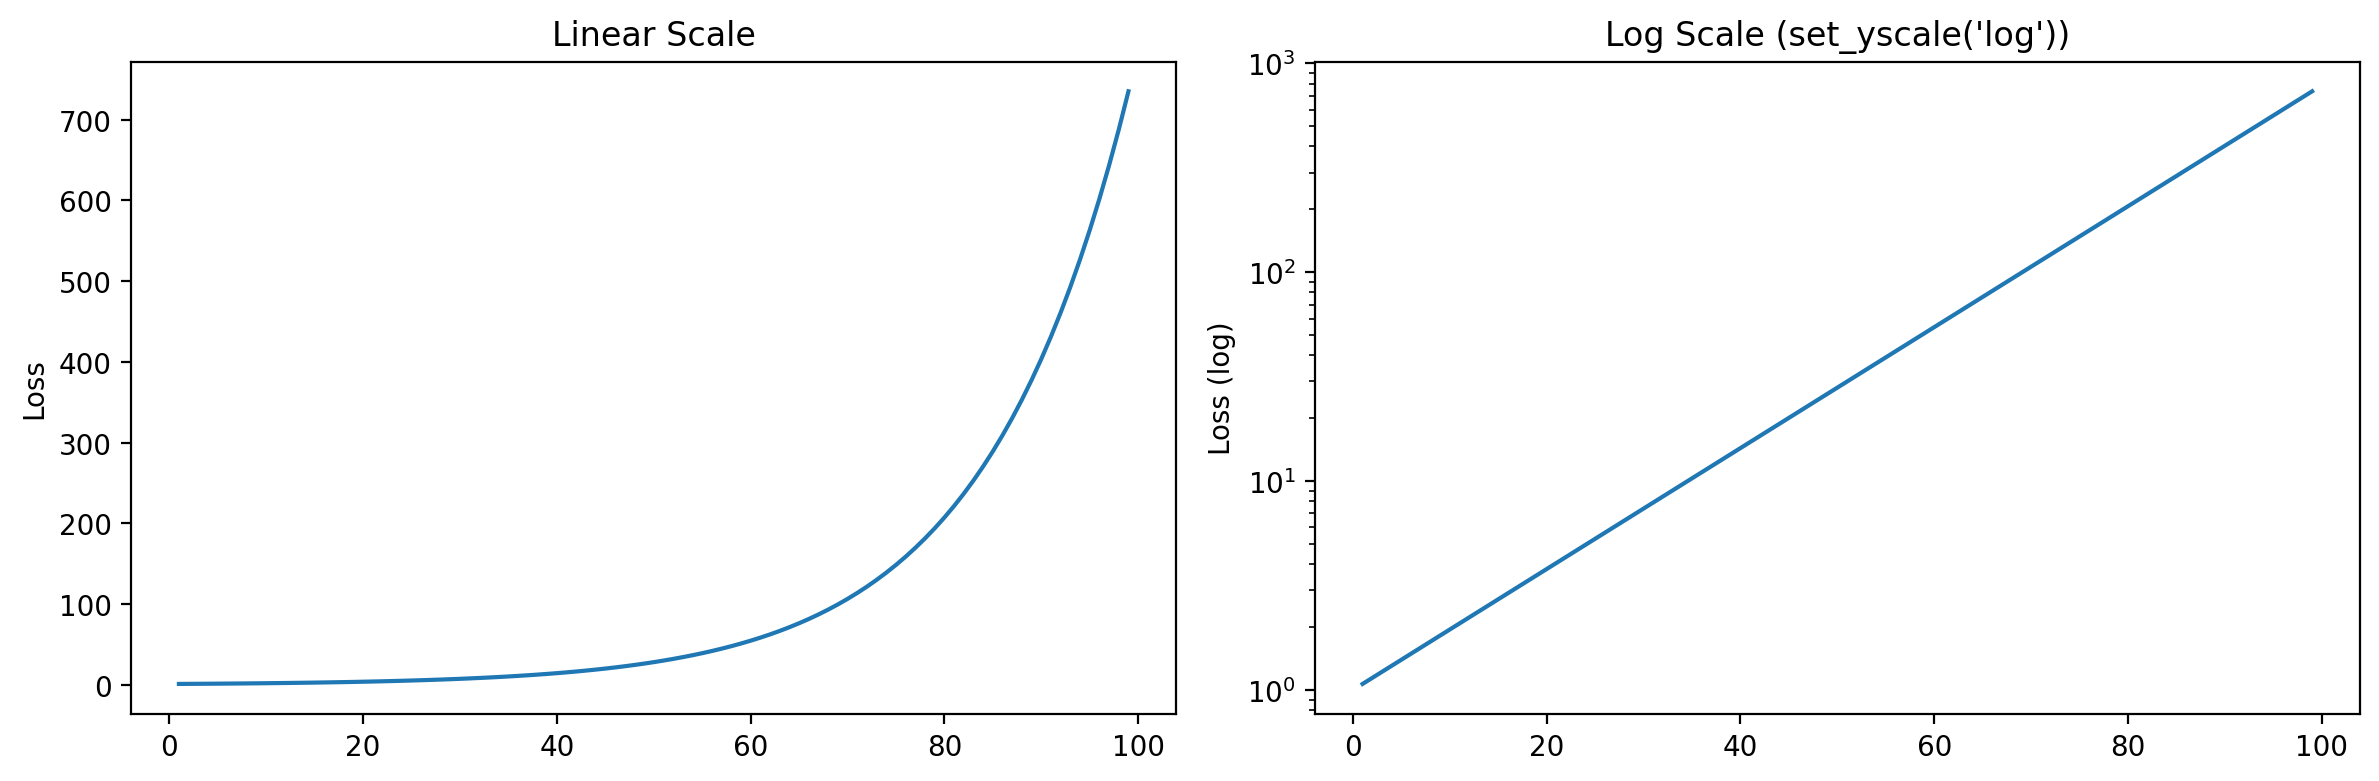

In [21]:
# Log scale — essential when values span orders of magnitude
# Used for: learning rate schedules, loss curves, hyperparameter grids

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(1, 100)
y = np.exp(x / 15)

# Linear scale — hard to see early behavior
axes[0].plot(x, y)
axes[0].set_title("Linear Scale")
axes[0].set_ylabel("Loss")

# Log scale — reveals structure at all scales
axes[1].plot(x, y)
axes[1].set_yscale('log')   # THIS is the key line
axes[1].set_title("Log Scale (set_yscale('log'))")
axes[1].set_ylabel("Loss (log)")

# Other options: ax.set_xscale('log') for x-axis
# 'symlog' for data that includes zero or negative values

plt.tight_layout()
plt.show()

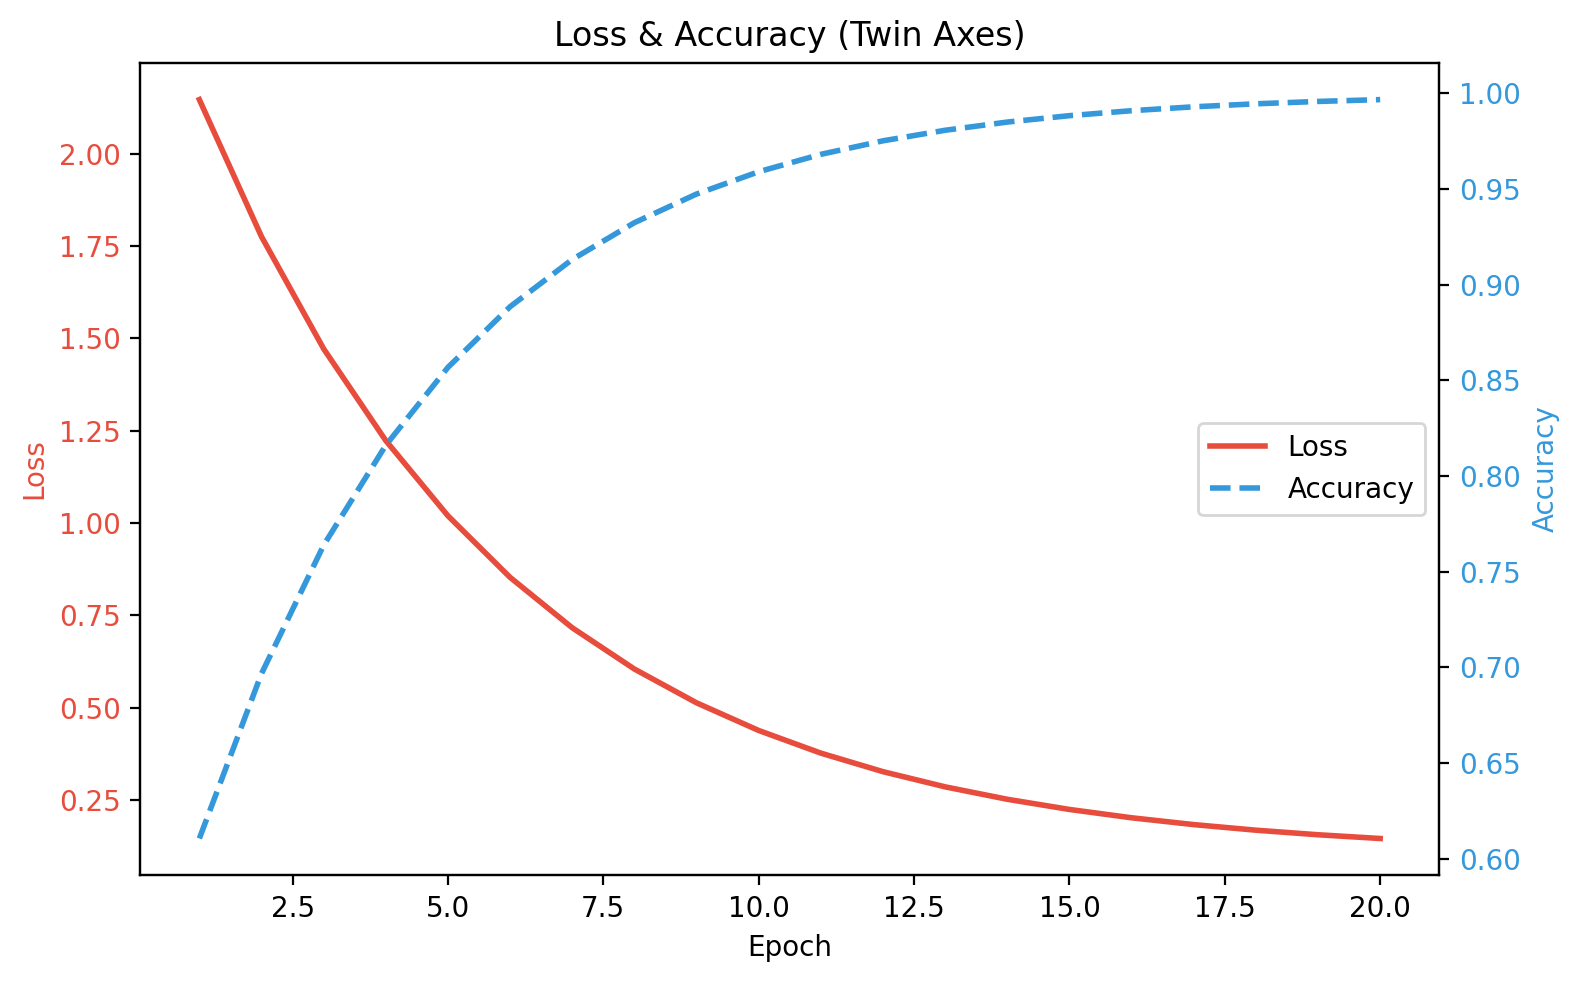

In [22]:
# Twin axes — two different y-scales on the same plot
# Used when plotting loss AND accuracy together (different ranges)

epochs = np.arange(1, 21)
loss = 2.5 * np.exp(-epochs / 5) + 0.1
accuracy = 1 - 0.5 * np.exp(-epochs / 4)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Left y-axis: loss
color1 = '#e74c3c'
ax1.plot(epochs, loss, color=color1, linewidth=2, label='Loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Right y-axis: accuracy (shares the same x-axis)
ax2 = ax1.twinx()  # THIS creates the twin axis
color2 = '#3498db'
ax2.plot(epochs, accuracy, color=color2, linewidth=2, linestyle='--', label='Accuracy')
ax2.set_ylabel("Accuracy", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title("Loss & Accuracy (Twin Axes)")
plt.tight_layout()
plt.show()

## 11. Saving Figures

Every ML project needs to export plots for papers, reports, or dashboards.

Saving examples (commented out to avoid file creation):
  fig.savefig('plot.png', dpi=150, bbox_inches='tight')
  fig.savefig('plot.pdf', bbox_inches='tight')


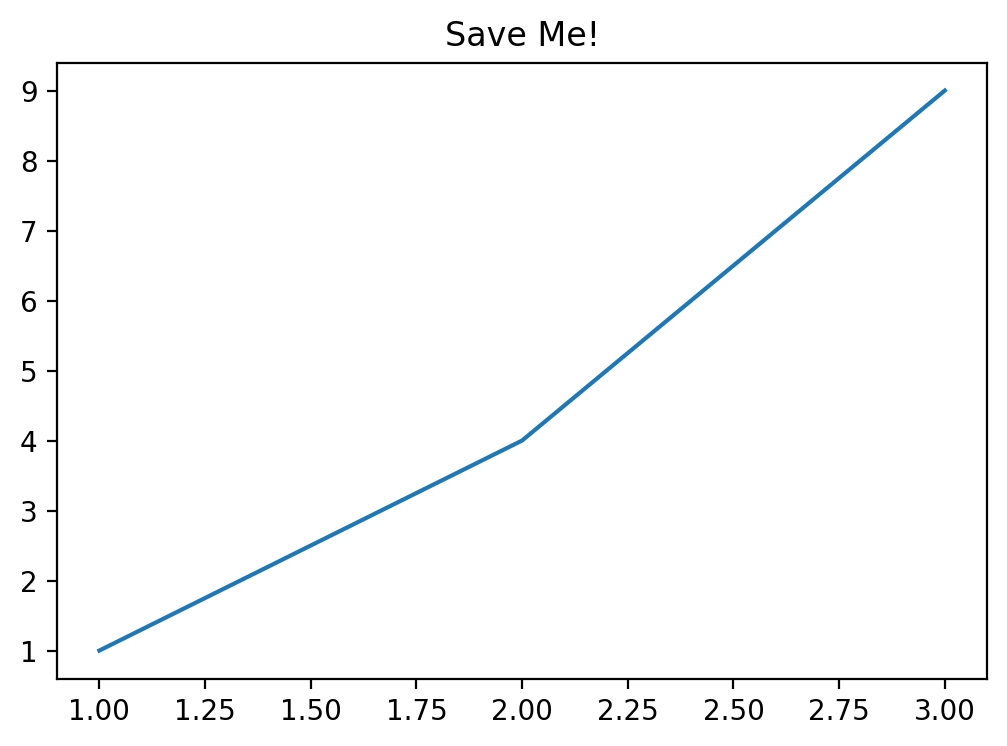

In [23]:
# fig.savefig() — must be called BEFORE plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title("Save Me!")

# Common formats:
# fig.savefig('plot.png', dpi=150, bbox_inches='tight')  # PNG for web/slides
# fig.savefig('plot.pdf', bbox_inches='tight')            # PDF for papers
# fig.savefig('plot.svg', bbox_inches='tight')            # SVG for web (vector)

# Key parameters:
# dpi=150 or 300    — resolution (300 for print, 150 for screen)
# bbox_inches='tight' — crop whitespace (almost always use this)
# transparent=True   — transparent background
# facecolor='white'  — force white background

print("Saving examples (commented out to avoid file creation):")
print("  fig.savefig('plot.png', dpi=150, bbox_inches='tight')")
print("  fig.savefig('plot.pdf', bbox_inches='tight')")
plt.show()

## 12. Real ML/AI Plotting Patterns

Complete, realistic examples of plots you'll encounter in ML projects.

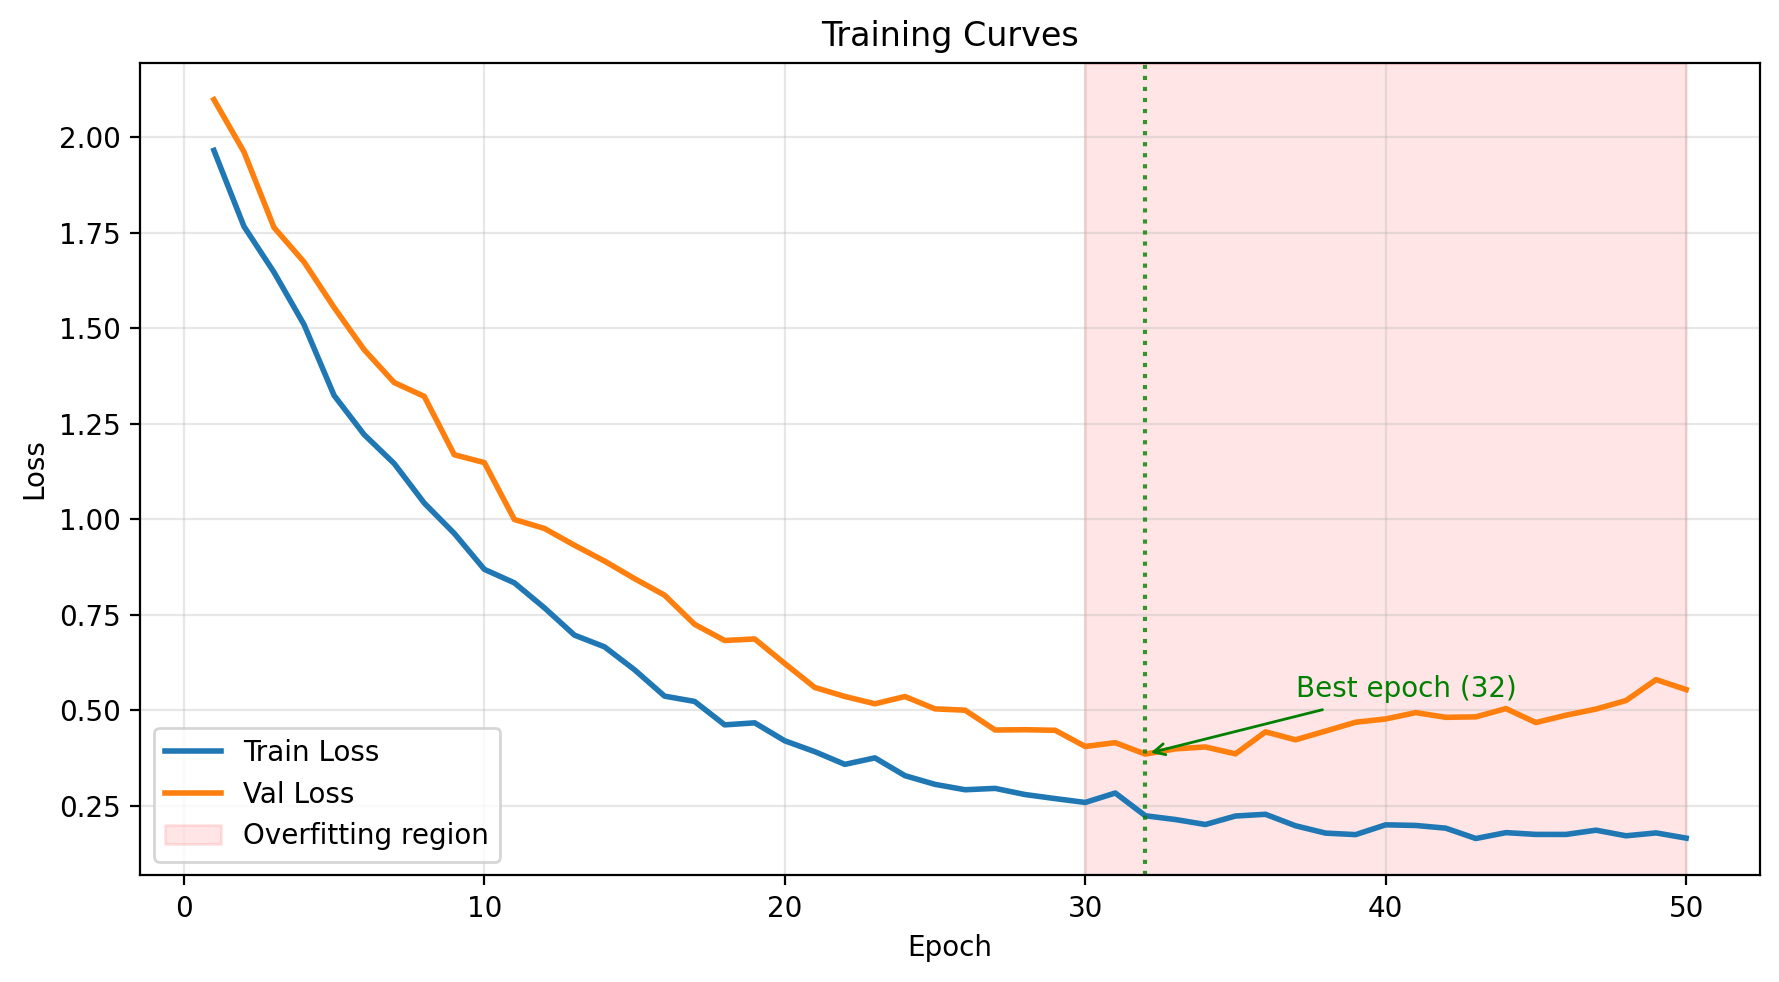

In [24]:
# Pattern 1: Training curves — loss and accuracy over epochs
# THE most common plot in deep learning

rng = np.random.default_rng(42)
epochs = np.arange(1, 51)
train_loss = 2.0 * np.exp(-epochs / 10) + 0.15 + rng.normal(0, 0.02, 50)
val_loss = 2.0 * np.exp(-epochs / 12) + 0.25 + rng.normal(0, 0.03, 50)
# Simulate overfitting after epoch 30
val_loss[30:] += np.linspace(0, 0.3, 20)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, train_loss, label='Train Loss', linewidth=2)
ax.plot(epochs, val_loss, label='Val Loss', linewidth=2)

# Mark best epoch
best_epoch = np.argmin(val_loss) + 1
ax.axvline(x=best_epoch, color='green', linestyle=':', alpha=0.8)
ax.annotate(f'Best epoch ({best_epoch})',
            xy=(best_epoch, val_loss[best_epoch-1]),
            xytext=(best_epoch + 5, val_loss[best_epoch-1] + 0.15),
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green', fontsize=10)

# Shade overfitting region
ax.axvspan(30, 50, alpha=0.1, color='red', label='Overfitting region')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

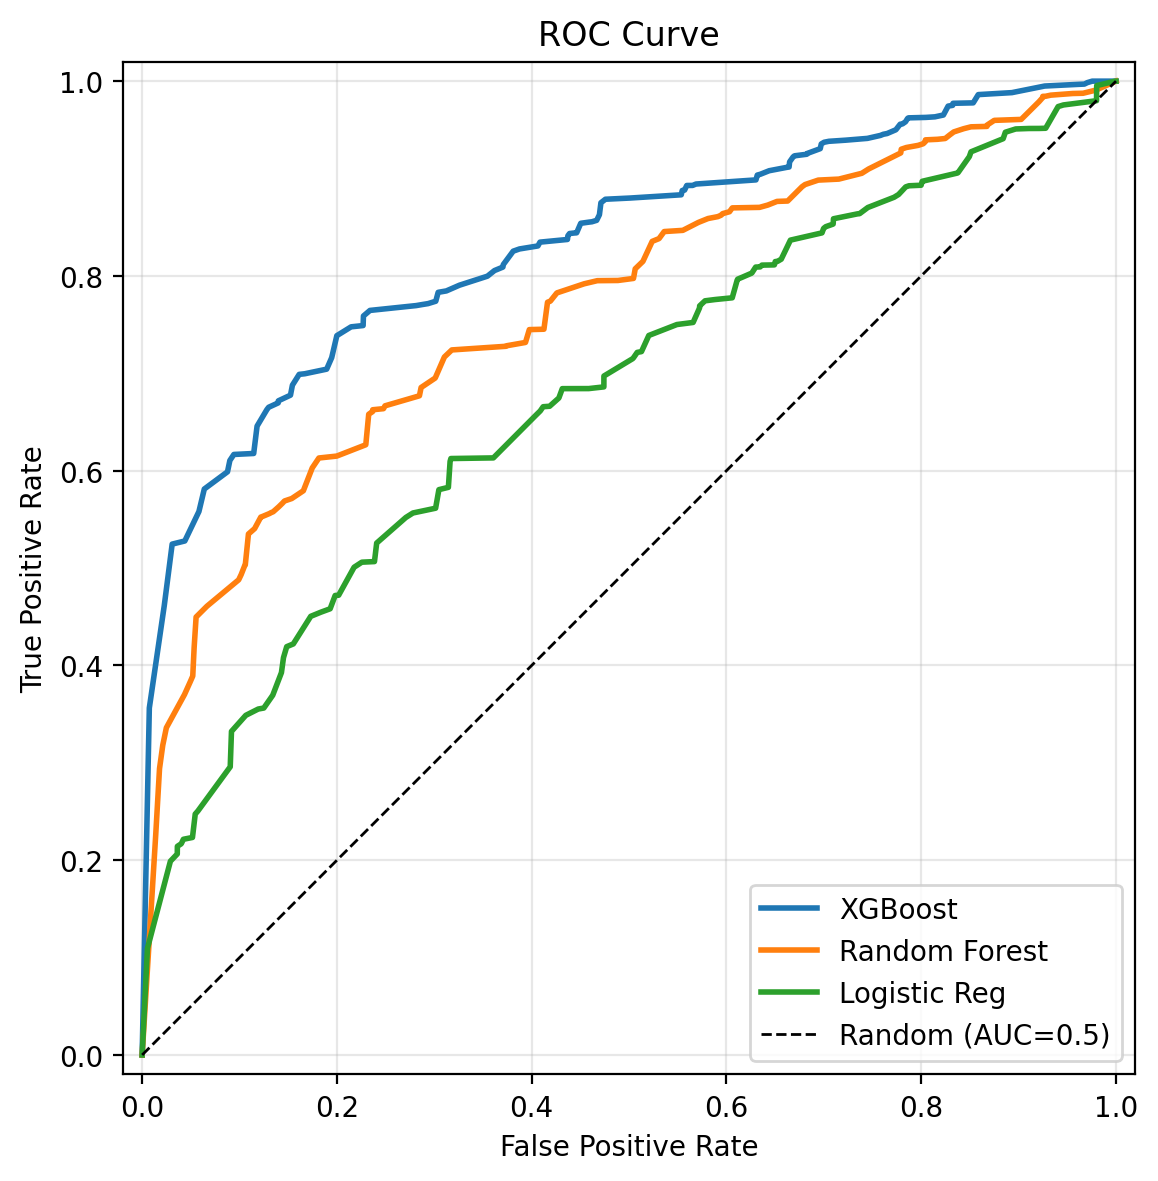

In [25]:
# Pattern 2: ROC Curve — standard classification evaluation
rng = np.random.default_rng(42)

# Simulate ROC data for 3 models
def fake_roc(auc_target, n=100):
    fpr = np.sort(rng.random(n))
    fpr = np.concatenate([[0], fpr, [1]])
    tpr = np.sort(fpr ** (1/auc_target - 0.2) + rng.normal(0, 0.02, len(fpr)))
    tpr = np.clip(tpr, 0, 1)
    tpr[0], tpr[-1] = 0, 1
    return fpr, tpr

fig, ax = plt.subplots(figsize=(6, 6))

for name, auc_val in [('XGBoost', 2.5), ('Random Forest', 2.0), ('Logistic Reg', 1.5)]:
    fpr, tpr = fake_roc(auc_val)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name}')

# Diagonal = random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

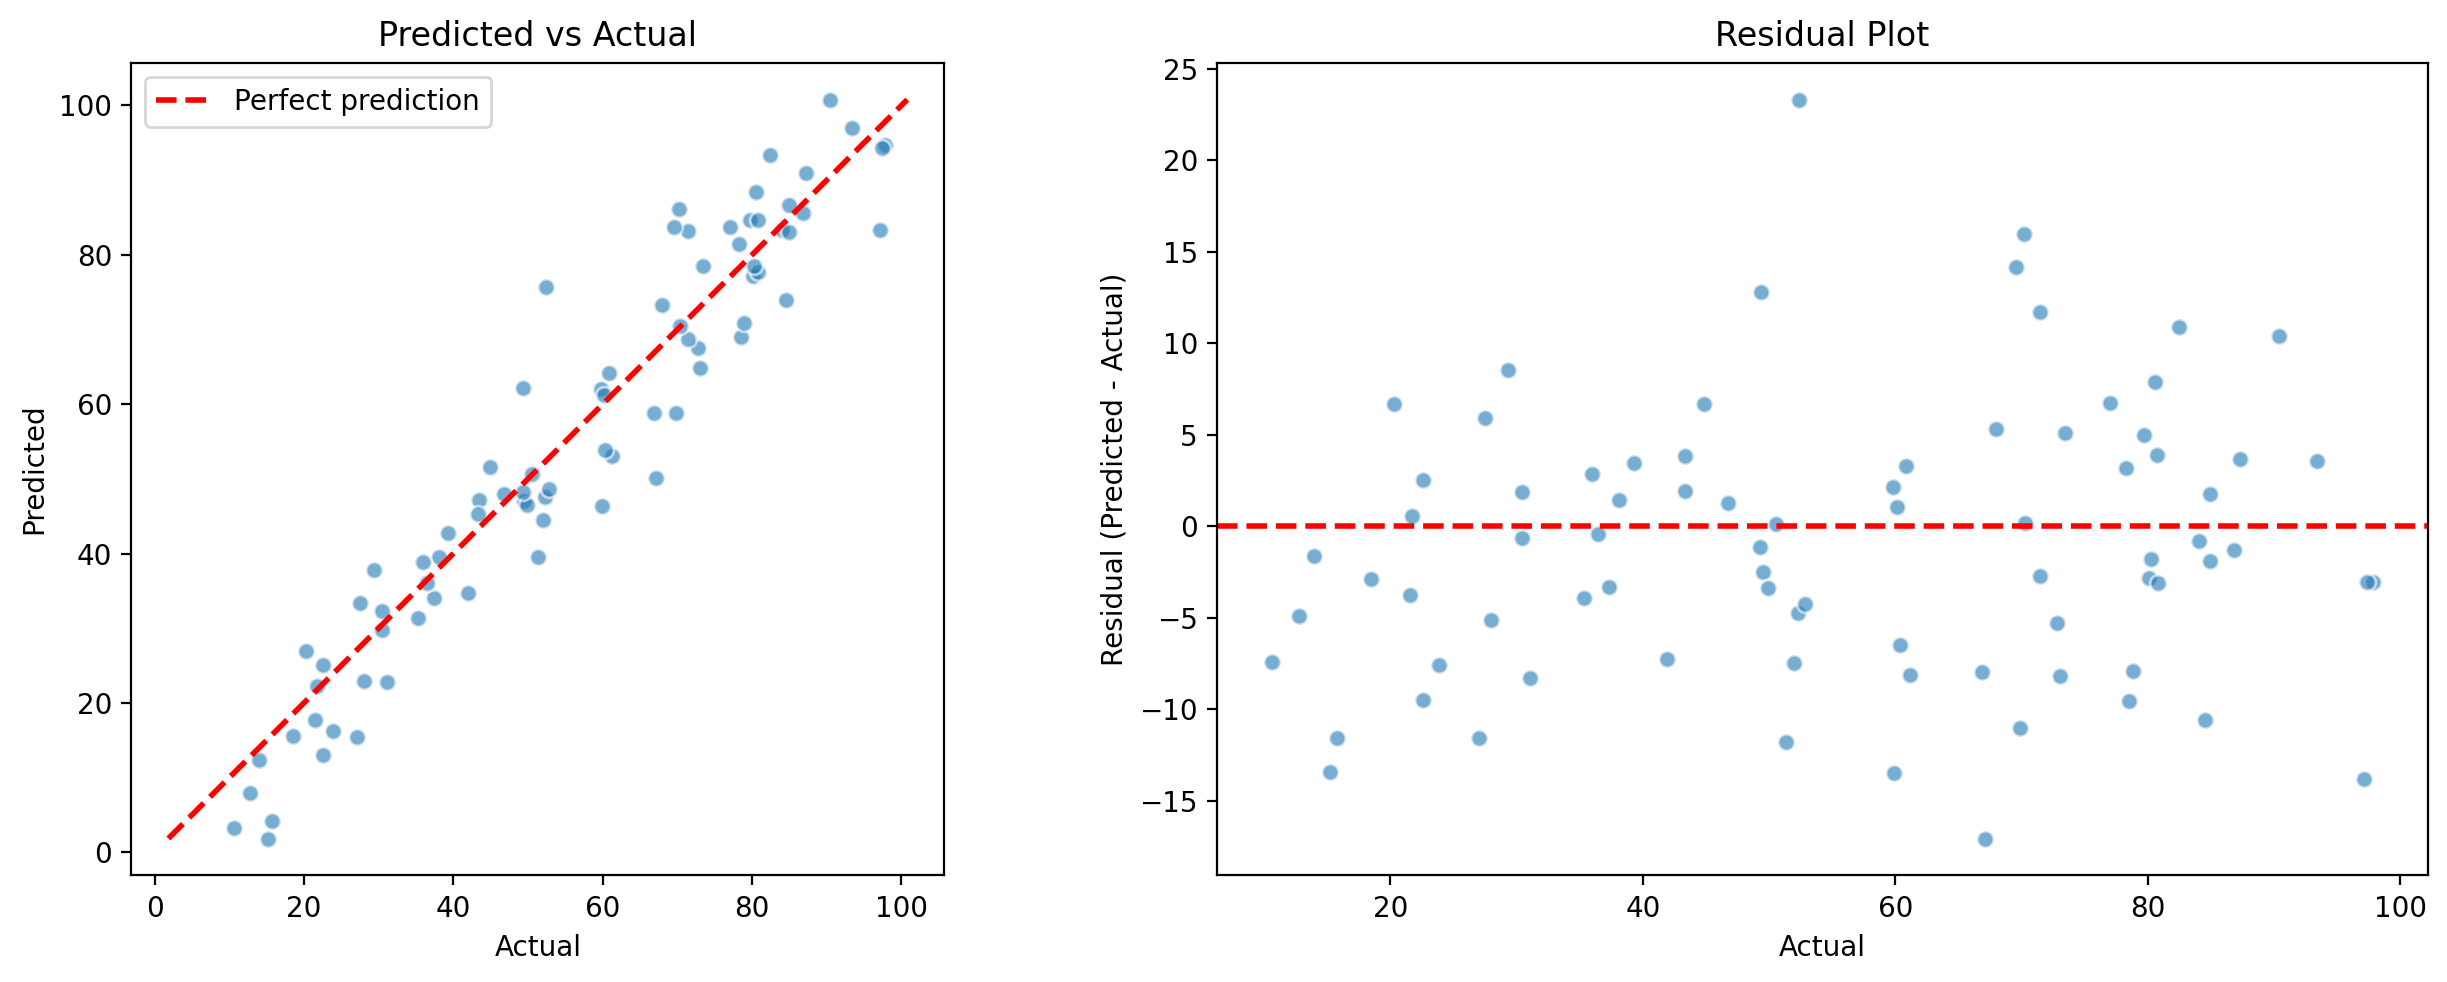

In [26]:
# Pattern 3: Prediction vs Actual — regression evaluation
rng = np.random.default_rng(42)

y_actual = rng.uniform(10, 100, 80)
y_predicted = y_actual + rng.normal(0, 8, 80)  # predictions with some noise

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Scatter of predicted vs actual
axes[0].scatter(y_actual, y_predicted, alpha=0.6, edgecolors='white')
# Perfect prediction line
lims = [min(y_actual.min(), y_predicted.min()), max(y_actual.max(), y_predicted.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()
axes[0].set_aspect('equal')

# Right: Residual plot
residuals = y_predicted - y_actual
axes[1].scatter(y_actual, residuals, alpha=0.6, edgecolors='white')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Residual (Predicted - Actual)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

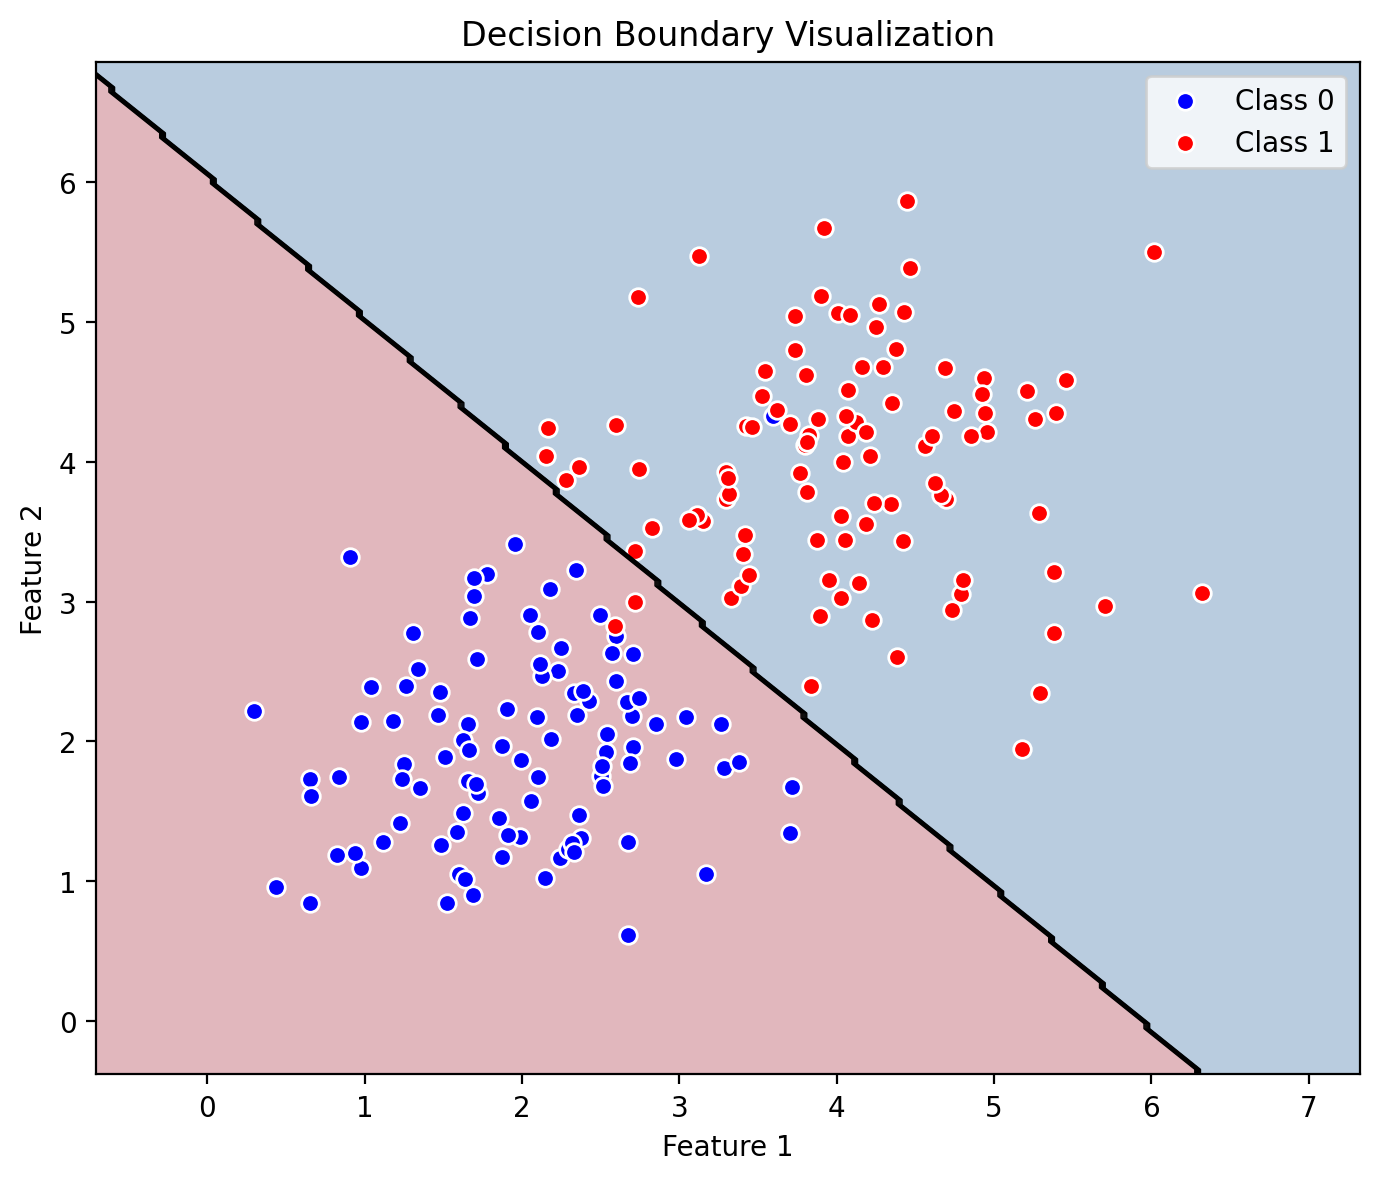

In [27]:
# Pattern 4: Decision boundary visualization
# This appears in classification demos and textbooks

rng = np.random.default_rng(42)

# Generate 2 classes
n = 100
X = np.vstack([rng.normal([2, 2], 0.8, (n, 2)),
               rng.normal([4, 4], 0.8, (n, 2))])
y = np.array([0]*n + [1]*n)

# Create a mesh grid for the background
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

# Simple "model": classify based on distance to class centers
center0, center1 = X[y==0].mean(axis=0), X[y==1].mean(axis=0)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
dist0 = np.linalg.norm(grid_points - center0, axis=1)
dist1 = np.linalg.norm(grid_points - center1, axis=1)
Z = (dist1 < dist0).astype(int).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))

# Background: decision regions
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
ax.contour(xx, yy, Z, colors='black', linewidths=0.5)  # decision boundary line

# Scatter the actual points
ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0', edgecolors='white', s=40)
ax.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1', edgecolors='white', s=40)

ax.set_title("Decision Boundary Visualization")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.tight_layout()
plt.show()

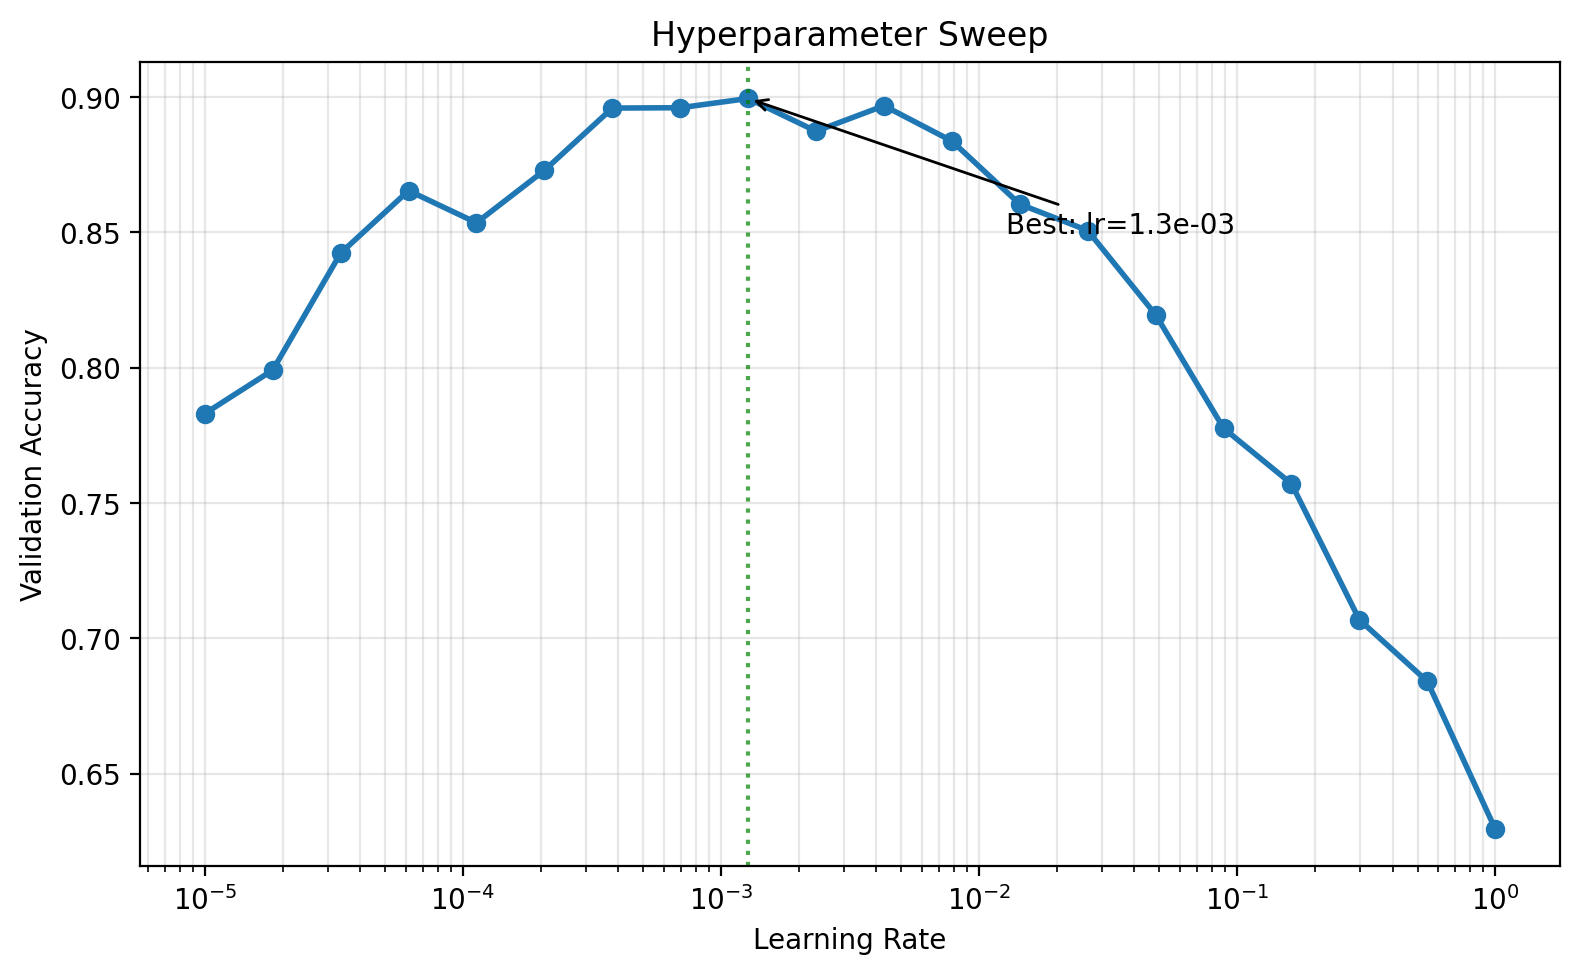

In [28]:
# Pattern 5: Learning rate / hyperparameter sweep
# Plotting validation performance across different hyperparameter values

learning_rates = np.logspace(-5, 0, 20)
# Simulate: performance peaks at ~0.001, drops at extremes
val_scores = 0.9 - 0.3 * (np.log10(learning_rates) + 3)**2 / 10
val_scores += np.random.default_rng(42).normal(0, 0.01, len(learning_rates))
val_scores = np.clip(val_scores, 0.5, 0.95)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(learning_rates, val_scores, 'o-', markersize=6, linewidth=2)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Hyperparameter Sweep")

# Mark the best
best_idx = np.argmax(val_scores)
ax.axvline(x=learning_rates[best_idx], color='green', linestyle=':', alpha=0.7)
ax.annotate(f'Best: lr={learning_rates[best_idx]:.1e}',
            xy=(learning_rates[best_idx], val_scores[best_idx]),
            xytext=(learning_rates[best_idx]*10, val_scores[best_idx]-0.05),
            arrowprops=dict(arrowstyle='->'), fontsize=10)

ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

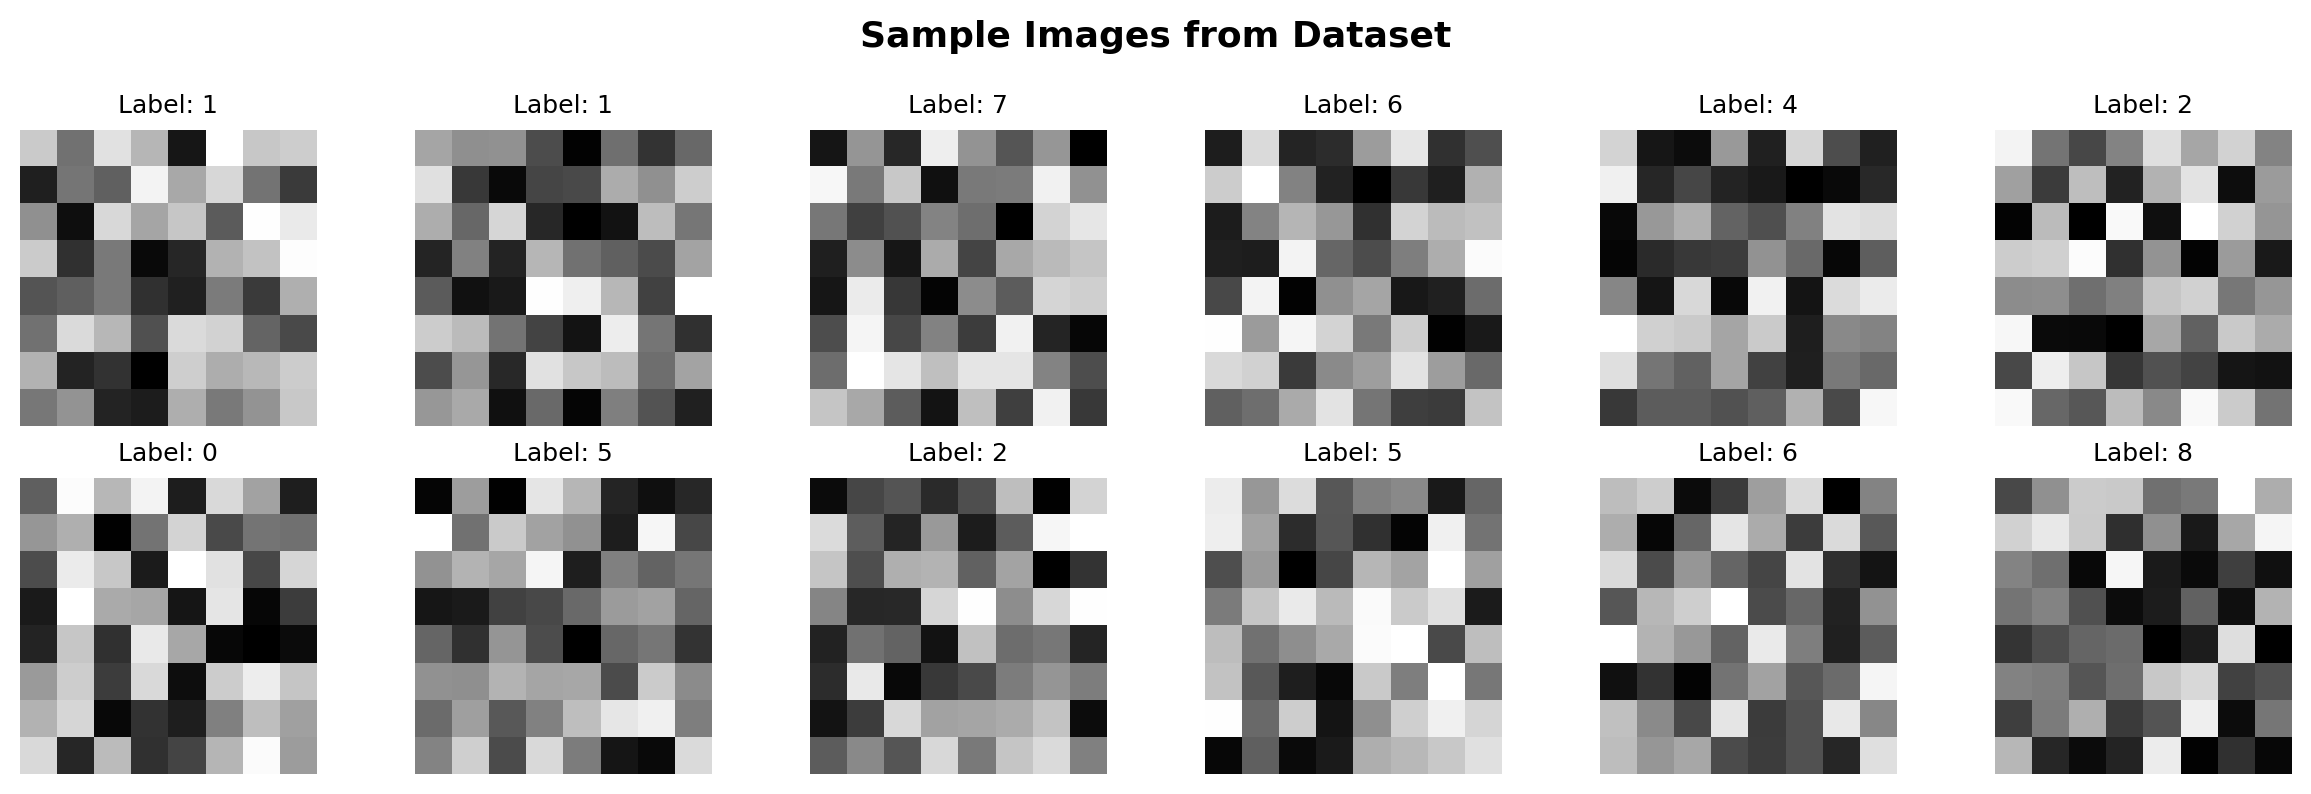

In [29]:
# Pattern 6: Image grid — displaying dataset samples (computer vision)
rng = np.random.default_rng(42)

# Simulate 8x8 grayscale images (like sklearn's digits dataset)
images = rng.random((12, 8, 8))
labels = rng.integers(0, 10, 12)

fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=9)
    ax.axis('off')  # Hide tick marks and borders

fig.suptitle("Sample Images from Dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

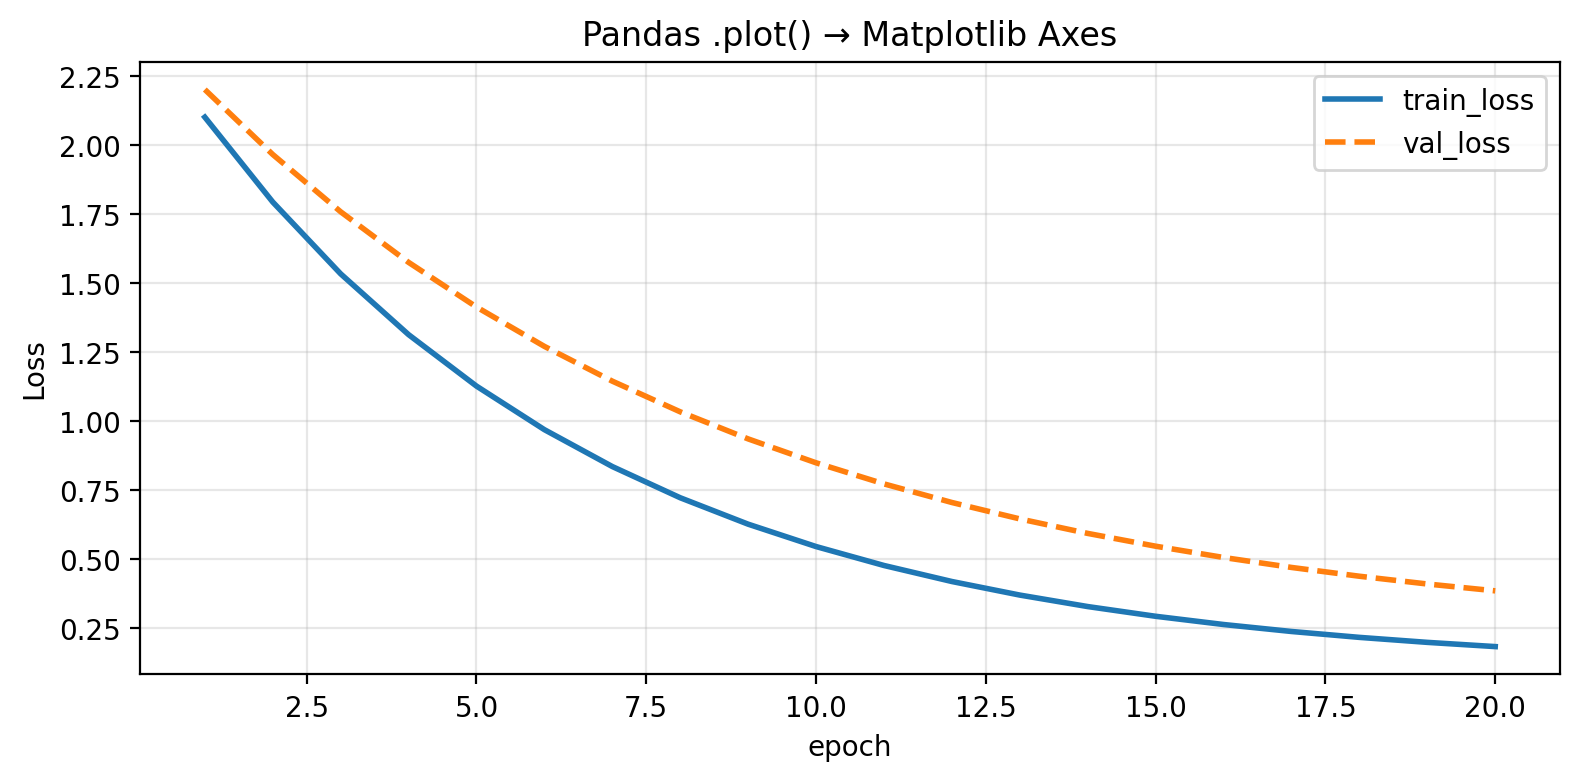

In [30]:
# Pattern 7: Pandas integration — df.plot() uses matplotlib under the hood
import pandas as pd

rng = np.random.default_rng(42)
df = pd.DataFrame({
    'epoch': range(1, 21),
    'train_loss': 2.0 * np.exp(-np.arange(20) / 6) + 0.1,
    'val_loss': 2.0 * np.exp(-np.arange(20) / 8) + 0.2,
})

# Pandas .plot() returns a matplotlib Axes — you can customize it further
ax = df.plot(x='epoch', y=['train_loss', 'val_loss'],
             figsize=(8, 4), linewidth=2, style=['-', '--'])
ax.set_ylabel("Loss")
ax.set_title("Pandas .plot() → Matplotlib Axes")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# This is why understanding matplotlib matters:
# Pandas creates the plot, but you customize it with matplotlib

## Quick Reference

| What you want | Code | Notes |
|---|---|---|
| Create figure | `fig, ax = plt.subplots(figsize=(8,5))` | OOP style (preferred) |
| Create subplots | `fig, axes = plt.subplots(2, 3)` | Access via `axes[row, col]` |
| Line plot | `ax.plot(x, y, 'r--', label='name')` | Color + linestyle shorthand |
| Scatter | `ax.scatter(x, y, c=labels, cmap='viridis')` | `c` for color-coding |
| Bar | `ax.bar(x, heights)` / `ax.barh(y, widths)` | Vertical / horizontal |
| Histogram | `ax.hist(data, bins=30, density=True)` | `density=True` for probability |
| Heatmap | `ax.imshow(matrix, cmap='Blues')` | Add `plt.colorbar()` |
| Box plot | `ax.boxplot(data_list, labels=names)` | Compare distributions |
| Title/labels | `ax.set_title()`, `ax.set_xlabel()` | Note: `set_` prefix in OOP |
| Legend | `ax.legend(loc='upper right')` | Needs `label=` in plot calls |
| Grid | `ax.grid(True, alpha=0.3)` | `alpha` controls opacity |
| Log scale | `ax.set_yscale('log')` | Or `ax.semilogx()` |
| Reference line | `ax.axhline(y=0)` / `ax.axvline(x=5)` | Horizontal / vertical |
| Fill region | `ax.fill_between(x, y1, y2, alpha=0.2)` | Confidence intervals |
| Twin y-axis | `ax2 = ax1.twinx()` | Two scales, one x-axis |
| Annotation | `ax.annotate('text', xy=..., xytext=...)` | With optional arrow |
| Save | `fig.savefig('plot.png', dpi=150, bbox_inches='tight')` | Before `plt.show()` |
| Style | `plt.style.use('seaborn-v0_8')` | Global style change |
| Close figure | `plt.close(fig)` | Prevent memory leaks in loops |